In [ ]:
!pip install jraph e3nn-jax

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.0/173.0 kB 7.0 MB/s eta 0:00:00


This is a small demonstration or tutorial on group-equivariant Deep Learning Architecture, with a focus on geometric deep learning. This subset considers the groups of reflections, translations and rotations, which together form the Euclidean Group E(n) in n dimensions. A library specifically developed for geomnetric deep-learning in the three-dimensional world is e3nn. In this tutorial we use the jax version. Jax is a relatively new lbrary thatis used increasingly instead of pytorch. The programming style is slightly different with a focus on more functional than object oriented language. Some advantages are funcions such as vmap and jit, which allow for seamless vectorization and Just-In-Time complication to accelerate performance.

E3nn is one of several possible architectures that can be used for equivariant learning. Other options are for example Vector-Neurons, which however are restricted to maximally l1 tensor features. E3nn uses a spherical harmonics basis expansion which enables feature computations of arbitrary l-rank features. The Clebsh-Gordan coefficients which describe how tensor-products of equivariant features can be decomposed into direct products of irreducible group representations transform is implemented efficiently.

Within this Notebook, a short introction will be given. The aim will be reproducing the research presented by a NeurIPS 2022 paper called:
"Unsupervised Learning of Group Invariant and Equivariant Representations".

This paper applies the concept of autoencoders to learn a group-invariant latent representation along with the group-transformation of the input-object. This enables unsupervised learning of a more effective latent space, where the information is independent to group-transformations. Additionally, the group-transformation with respect to some canonical identiy element can be predicted.

In [ ]:
import time

import flax
import jax
import jax.numpy as jnp
import jraph
import optax
from tqdm.auto import tqdm

import e3nn_jax as e3nn


We start with the dataset, which is chosen to be 6 tetris shapes with 4-blocks each. Optionally, one can include 2 further shapes are chiral counterparts. A model that is equivariant to the rotation group $SO(3)$, it will treat these two distinct shapes as identical. However, if it is equivariant to the full Euclidean group $E(3)$—which includes reflections—it can formally distinguish between these "mirror images."

 The shapes are represented as graphs. Since Tetris blocks are defined by their spatial coordinates, one can use e3nn.radius_graph to automatically draw edges between any two blocks within a distance of 1.1 units. This transforms the raw coordinates into a structured connectivity map (the adjacency list), allowing a Graph Neural Network (GNN) to pass geometric messages between the nodes.

 We use jraph which is the Jax library for graph neural networks.

In [ ]:
def tetris() -> jraph.GraphsTuple:
    pos = [
        #[[0, 0, 0], [0, 0, 1], [1, 0, 0], [1, 1, 0]],  # chiral_shape_1
       # [[1, 1, 1], [1, 1, 2], [2, 1, 1], [2, 0, 1]],  # ch0iral_shape_2
        [[0, 0, 0], [1, 0, 0], [0, 1, 0], [1, 1, 0]],  # square
        [[0, 0, 0], [0, 0, 1], [0, 0, 2], [0, 0, 3]],  # line
        [[0, 0, 0], [0, 0, 1], [0, 1, 0], [1, 0, 0]],  # corner
        [[0, 0, 0], [0, 0, 1], [0, 0, 2], [0, 1, 0]],  # L
        [[0, 0, 0], [0, 0, 1], [0, 0, 2], [0, 1, 1]],  # T
        [[0, 0, 0], [1, 0, 0], [1, 1, 0], [2, 1, 0]],  # zigzag
    ]
    pos = jnp.array(pos, dtype=jnp.float32)
    labels = jnp.arange(8)

    graphs = []

    for p, l in zip(pos, labels):
        senders, receivers = e3nn.radius_graph(p, 1.1)

        graphs += [
            jraph.GraphsTuple(
                nodes=p.reshape((4, 3)),  # [num_nodes, 3]
                edges=None,
                globals=l[None],  # [num_graphs]
                senders=senders,  # [num_edges]
                receivers=receivers,  # [num_edges]
                n_node=jnp.array([len(p)]),  # [num_graphs]
                n_edge=jnp.array([len(senders)]),  # [num_graphs]
            )
        ]

    return jraph.batch(graphs)


Let us print the tetris graphs. Note that the senders and receivers have equal length and define a disjoint connectivity information corresponding to the isolated tetris shapes. All tetris shaoes have 4 nodes and 6 edges.

In [ ]:
tetris_graphs = tetris()
print(tetris_graphs)

GraphsTuple(nodes=Array([[0., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 1., 0.],
       [0., 0., 0.],
       [0., 0., 1.],
       [0., 0., 2.],
       [0., 0., 3.],
       [0., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 0.],
       [0., 0., 1.],
       [0., 0., 2.],
       [0., 1., 0.],
       [0., 0., 0.],
       [0., 0., 1.],
       [0., 0., 2.],
       [0., 1., 1.],
       [0., 0., 0.],
       [1., 0., 0.],
       [1., 1., 0.],
       [2., 1., 0.]], dtype=float32), edges=None, receivers=Array([ 1,  2,  0,  3,  0,  3,  1,  2,  5,  4,  6,  5,  7,  6,  9, 10, 11,
        8,  8,  8, 13, 15, 12, 14, 13, 12, 17, 16, 18, 19, 17, 17, 21, 20,
       22, 21, 23, 22], dtype=int32), senders=Array([ 0,  0,  1,  1,  2,  2,  3,  3,  4,  5,  5,  6,  6,  7,  8,  8,  8,
        9, 10, 11, 12, 12, 13, 13, 14, 15, 16, 17, 17, 17, 18, 19, 20, 21,
       21, 22, 22, 23], dtype=int32), globals=Array([0, 1, 2, 3, 4, 5], dtype=int32), n_node=

Let us plot some of the tetris shapes to get a better feeling for the data.

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def plot_tetris_graphs(batched_graph: jraph.GraphsTuple, indices: list = None):
    """
    Plots the 3D nodes and edges for each shape in a jraph batch.

    Args:
        batched_graph: The jraph.GraphsTuple containing multiple shapes.
        indices: A list of integers (e.g., [0, 2]) specifying which shapes to plot.
                 If None, all shapes in the batch are plotted.
    """
    # Unbatch the graphs to process them individually
    graphs = jraph.unbatch(batched_graph)

    # Filter graphs based on indices if provided
    if indices is not None:
        try:
            graphs = [graphs[i] for i in indices]
        except IndexError as e:
            print(f"Error: One or more indices in {indices} are out of range for the batch.")
            return

    num_graphs = len(graphs)
    if num_graphs == 0:
        print("No graphs to plot.")
        return

    # Create a grid of subplots
    cols = 3
    rows = (num_graphs + cols - 1) // cols
    fig = plt.figure(figsize=(15, 5 * rows))

    for i, graph in enumerate(graphs):
        ax = fig.add_subplot(rows, cols, i + 1, projection='3d')

        # Extract node positions (x, y, z)
        pos = np.array(graph.nodes)
        x, y, z = pos[:, 0], pos[:, 1], pos[:, 2]

        # Plot the nodes
        ax.scatter(x, y, z, s=200, c='royalblue', edgecolors='black', alpha=0.8)

        # Plot edges
        if graph.senders is not None:
            for s, r in zip(graph.senders, graph.receivers):
                ax.plot([x[s], x[r]], [y[s], y[r]], [z[s], z[r]], color='black', alpha=0.5)

        # Formatting - Using indices[i] for the title if indices were provided
        display_label = indices[i] if indices is not None else i
        ax.set_title(f"Graph Index: {display_label} (Label: {graph.globals[0]})")

        # Set limits to maintain scale consistency
        ax.set_xlim(0, 3)
        ax.set_ylim(0, 3)
        ax.set_zlim(0, 3)

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

    plt.tight_layout()
    plt.show()


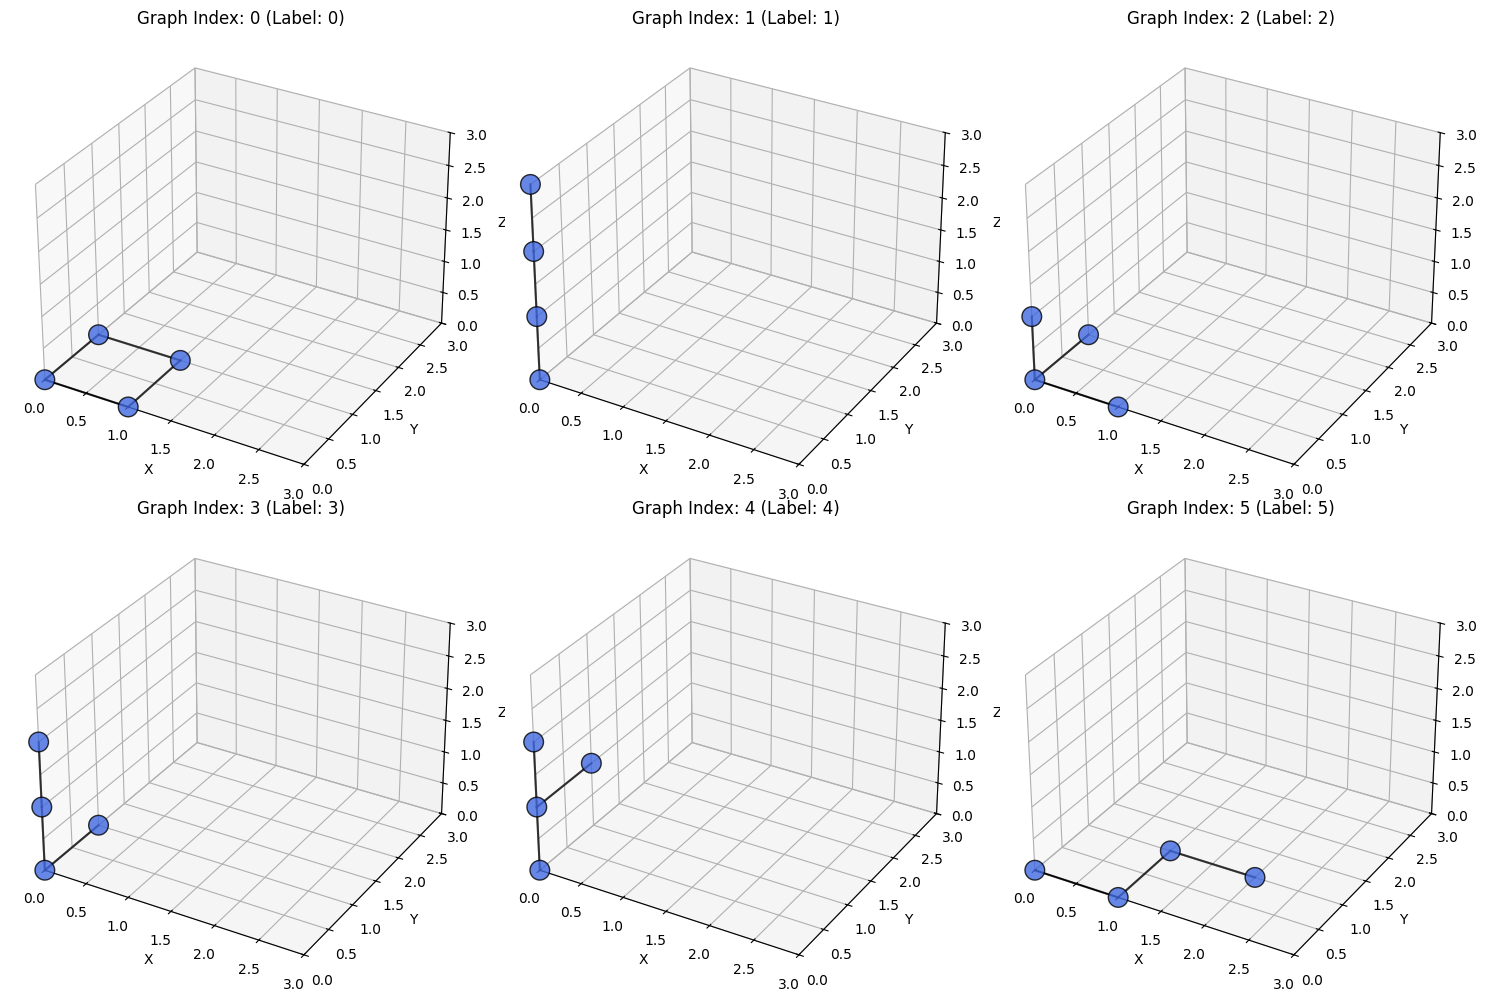

In [ ]:
plot_tetris_graphs(tetris_graphs)

A sensible start is the definition of the Message Passing Layer. Using the receiver and sender connectivity, the relative distance is used as translation invariant feature. The SO(3) equivariant features are then computed on this translation invariant space through the spherical harmonics functions. While the these fucntions are commonly understood to operate on the unit-shpere (i.e. the direction defined by the relative distance) it is possible to extend the concept to the real three-dimensional space. The update-funcion of the edges is performed by producing the tensor product of the spherical harmonics with the sender features.

The nodees are updated by considering the target irreducible of node fature. These are passed through a linear layer. The scalar activation function is a non-linear function applied to a scalar representation of the input feature. If the input feature is a vector, this scalar might be the lenght, for a matrix it could be the trace or determinant. The reason is that nonlinearities can only
be applied to scalar representations without destroying equivariance.

A sensible practice is the usage of a skip-connection, which has been shown to have significant positive effects on deep learning.

Jraph handles most of the underlying computation. It is sufficient to specify these two function to define a GNN message passing layer.


In [ ]:
class Layer(flax.linen.Module):
    target_irreps: e3nn.Irreps
    denominator: float
    sh_lmax: int = 3

    @flax.linen.compact
    def __call__(self, graphs, positions):
        target_irreps = e3nn.Irreps(self.target_irreps)

        def update_edge_fn(edge_features, sender_features, receiver_features, globals):
            sh = e3nn.spherical_harmonics(
                list(range(1, self.sh_lmax + 1)),
                positions[graphs.receivers] - positions[graphs.senders],
                True,
            )
            return e3nn.concatenate(
                [sender_features, e3nn.tensor_product(sender_features, sh)]
            ).regroup()

        def update_node_fn(node_features, sender_features, receiver_features, globals):
            node_feats = receiver_features / self.denominator
            node_feats = e3nn.flax.Linear(target_irreps, name="linear_pre")(node_feats)
            node_feats = e3nn.scalar_activation(node_feats)
            node_feats = e3nn.flax.Linear(target_irreps, name="linear_post")(node_feats)
            shortcut = e3nn.flax.Linear(
                node_feats.irreps, name="shortcut", force_irreps_out=True
            )(node_features)
            return shortcut + node_feats

        return jraph.GraphNetwork(update_edge_fn, update_node_fn)(graphs)


The full model will receive the graphs as input. These are currently only a set of positions and edges. The positions transform as l1 tensors and flip sign under reflection, which makes then odd.

A fantastic feature of e3nn is that we can just specify the irreducible features that one wants to compute on and then do deep-learning operations, such as weighted tensor products on them. This makes defining the layers easy.

In this first test, let the last layer be six even scalars, i.e. features which are invariant to E(3).

In [ ]:

class Model(flax.linen.Module):
    @flax.linen.compact
    def __call__(self, graphs, break_symmetry= True):
        positions = e3nn.IrrepsArray("1o", graphs.nodes)

        if break_symmetry:
          node_indices = jnp.arange(len(positions)).reshape(-1, 1)
          node_feats = e3nn.IrrepsArray("1x0e", node_indices)

          graphs = graphs._replace(nodes=node_feats)
        else:
         graphs = graphs._replace(nodes=jnp.ones((len(positions), 1)))

        #layers = 2 * ["32x0e + 32x0o + 8x1e + 8x1o + 8x2e + 8x2o"] + ["0o + 7x0e"]
        layers = 2 * ["32x0e + 32x0o + 8x1e + 8x1o + 8x2e + 8x2o"] + ["6x0e"]
        for irreps in layers:
            graphs = Layer(irreps, 1.5)(graphs, positions)

        # Readout logits
        pred = e3nn.scatter_sum(
            graphs.nodes.array, nel=graphs.n_node
        )  # [num_graphs, 1 + 7]
        odd, even1, even2 = pred[:, :1], pred[:, 1:2], pred[:, 2:]
        #logits = jnp.concatenate([odd * even1, -odd * even1, even2], axis=1)
        logits = pred
        # assert logits.shape == (len(graphs.n_node), 8)  # [num_graphs, num_classes]
        assert logits.shape == (len(graphs.n_node), 6)  # [num_graphs, num_classes]
        return logits


Training a model in JAX introduces a distinct paradigm shift from the stateful approach of PyTorch to a purely functional workflow. In the train function below, notice that the model parameters and optimizer state are not stored within the objects themselves; instead, they are passed explicitly into the update_fn as arguments and returned as updated versions.

 This design is what allows for the powerful @jax.jit decoration, which compiles the entire update step into a single, optimized XLA (Accelerated Linear Algebra) operation.

 By using jax.grad with has_aux=True, we simultaneously compute the gradients for backpropagation while "carrying along" auxiliary data like training accuracy. Furthermore, because JAX is stateless, you must manually manage the randomness via a jax.random.PRNGKey, ensuring that the initialization and training are perfectly reproducible and mathematically transpare

In [ ]:

def train(steps=200):
    model = Model()

    # Optimizer
    opt = optax.adam(learning_rate=0.01)

    def loss_fn(params, graphs):
        logits = model.apply(params, graphs)
        labels = graphs.globals  # [num_graphs]

        loss = optax.softmax_cross_entropy_with_integer_labels(logits, labels)
        loss = jnp.mean(loss)
        return loss, logits

    @jax.jit
    def update_fn(params, opt_state, graphs):
        grad_fn = jax.grad(loss_fn, has_aux=True)
        grads, logits = grad_fn(params, graphs)
        labels = graphs.globals
        accuracy = jnp.mean(jnp.argmax(logits, axis=1) == labels)

        updates, opt_state = opt.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        return params, opt_state, accuracy

    # Dataset
    graphs = tetris()

    # Init
    init = jax.jit(model.init)
    params = init(jax.random.PRNGKey(3), graphs)
    opt_state = opt.init(params)

    # compile jit
    wall = time.perf_counter()
    print("compiling...", flush=True)
    _, _, accuracy = update_fn(params, opt_state, graphs)
    print(f"initial accuracy = {100 * accuracy:.0f}%", flush=True)
    print(f"compilation took {time.perf_counter() - wall:.1f}s")

    # Train
    wall = time.perf_counter()
    print("training...", flush=True)
    iter = 0
    for _ in tqdm(range(steps)):

        params, opt_state, accuracy = update_fn(params, opt_state, graphs)

        if accuracy == 1.0:
            break

        iter += 1

    print(f"final accuracy = {100 * accuracy:.0f}%")

    return params, opt_state, model, graphs

In [ ]:
trained_params, _, model_inst, base_data  = train(steps=200)

NameError: name 'tetris' is not defined

To verify that our model has truly learned the geometric principles of $E(3)$ rather than just memorizing the specific orientation of the input coordinates, we perform an evaluation on augmented data.

In this step, we apply random rotations, translations, and node permutations to the Tetris shapes before passing them through the network.If the architecture is successfully group-equivariant, it should achieve the exact same accuracy on this "scrambled" data as it did on the original training set.

 Unlike traditional CNNs that require massive data augmentation during training to learn these symmetries, an equivariant model built with e3nn-jax understands these transformations by design. This evaluation confirms that the model’s predictions are invariant to where the object is in space or how it is oriented, proving it has captured the fundamental geometry of the 3D shapes.

In [ ]:
def evaluate(params, model, base_graphs, key, rot=True, tr=True, perm=True):
    """
    Evaluates the trained model on a freshly augmented version of the dataset.
    """
    # 1. Generate the augmented test set
    test_graphs = augment_tetris(key, base_graphs, rot=rot, tr=tr, perm=perm)

    # 2. Run inference
    logits = model.apply(params, test_graphs)
    labels = test_graphs.globals

    # 3. Calculate metrics
    predictions = jnp.argmax(logits, axis=1)
    accuracy = jnp.mean(predictions == labels)

    print(f"\n--- Evaluation Results ---")
    print(f"Augmentations: Rot={rot}, Trans={tr}, Perm={perm}")
    print(f"Test Accuracy: {100 * accuracy:.2f}%")

    return accuracy

In [ ]:
# Evaluate on augmented data
eval_key = jax.random.PRNGKey(42)
evaluate(trained_params, model_inst, base_data, eval_key, rot=True, tr=True, perm=True)

NameError: name 'augment_tetris' is not defined

Now that we have show the basic principle with invariant vectors let us build something more sophisticated that makes use also of invariant vectors.

Following the architecture presented in the NeurIps 2022 paper "Unsupervised Learning of Group Invariant and Equivariant Representations"
we will learn an group-invariant representation of the inputs as well as a group-equivariant representation. The first will represent everything that represents the object itself, while the second will be used to learn the group transformation that has been applied to the object.

In essence, letting this transformation act on the canoncial (i.e. the untransformed, or equivalently the object transformed via the identity group operation) object reproduces the input object.

In [ ]:

import jax
import jax.numpy as jnp
import flax.linen as nn
import e3nn_jax as e3nn

class EquivModel(nn.Module):
    @nn.compact
    def __call__(self, graphs, break_symmetry = True ):
        # 1. Setup Input Features (Similar to your OHE/ones init)
        positions = e3nn.IrrepsArray("1o", graphs.nodes)
        if break_symmetry:
          node_indices = jnp.arange(len(positions)).reshape(-1, 1)
          node_feats = e3nn.IrrepsArray("1x0e", node_indices)
          graphs = graphs._replace(nodes=node_feats)
        else:
         graphs = graphs._replace(nodes=jnp.ones((len(positions), 1)))
         node_feats = e3nn.IrrepsArray("1x0e", jnp.ones((len(positions), 1)))

        graphs = graphs._replace(nodes=node_feats)

        # 2. Message Passing Layers (Analogous to ShapeGNN)
        layers = 6 * ["32x0e + 32x0o + 16x1e + 16x1o"] + ["1x0e + 2x1o"]
        for irreps in layers:
            # Assuming 'Layer' is your equivalent GNN block
            graphs = Layer(irreps, 1.5)(graphs, positions)

        # 3. Global Pooling (Analogous to your scatter mean)
        # This gives us graph-level scalar and vector embeddings
        pooled = e3nn.scatter_sum(graphs.nodes, nel=graphs.n_node)

        # 4. Extract Invariant (shape_embed) and Equivariant (vout)
        # Analogous to: shape_embed, point_embed = sout.chunk(2, dim=-1)
        shape_embed = pooled.filtered(keep="0e")

        # Analogous to: vout = scatter(vout, index=batch, dim=0, reduce="mean")
        # We grab the '1o' part and reshape it into two vectors (2, 3) per graph
        vout_all = pooled.filtered(keep="1o").array
        vout = vout_all.reshape((-1, 2, 3)) # [batch, 2_vectors, 3_dims]

        # 5. Get Rotation Matrix (Analogous to get_rotation_matrix_from_two_vector)
        v1 = vout[:, 0, :]
        v2 = vout[:, 1, :]

        rot_matrix = self.get_rotation_matrix_from_two_vector(v1, v2)
        # Optional: Translation (Analogous to transl_out)
        # If your model predicts translation, you'd extract it here similarly
        # transl_out = jnp.mean(positions.array, axis=0) # Dummy placeholder
        transl_out = e3nn.scatter_mean(positions.array, nel=graphs.n_node)
        return shape_embed, rot_matrix, vout, transl_out

    def get_rotation_matrix_from_two_vector(self, v1, v2):
        """Analogous to your PyTorch helper function"""
        # Normalize first vector (y1)
        u = v1 / (jnp.linalg.norm(v1, axis=-1, keepdims=True) + 1e-8)

        # Gram-Schmidt for second vector (y2)
        dot = jnp.einsum('bi,bi->b', u, v2)[..., None]
        w_raw = v2 - dot * u
        w = w_raw / (jnp.linalg.norm(w_raw, axis=-1, keepdims=True) + 1e-8)

        # Fallback logic to avoid nans at initialization
        _, fallback_w = self.get_orthogonal_basis(u)
        is_degenerate = jnp.linalg.norm(w_raw, axis=-1) < 1e-4
        w = jnp.where(is_degenerate[..., None], fallback_w, w)

        # Third vector via cross product (y3)
        last_v = jnp.cross(u, w)

        # Stack to form rotation matrix R = [u | w | last_v]
        return jnp.stack([u, w, last_v], axis=-1)

    def get_orthogonal_basis(self, v):
        """Fixed axis fallback for stability"""
        condition = jnp.abs(v[..., 0]) < 0.9
        helper = jnp.where(condition[..., None], jnp.array([1., 0., 0.]), jnp.array([0., 1., 0.]))
        u = jnp.cross(v, helper)
        u = u / (jnp.linalg.norm(u, axis=-1, keepdims=True) + 1e-8)
        w = jnp.cross(v, u)
        return u, w


For more control we use a function that enables the precise application  of a user-defined SE(3) group transformation to a graph.

In [ ]:
def transform_tetris_explicit(key, graph, rotations, translations, permute=False):
    n_graphs = graph.n_node.shape[0]
    keys = jax.random.split(key, n_graphs)
    node_offsets = jnp.cumsum(jnp.concatenate([jnp.array([0]), graph.n_node]))
    new_graphs = []

    for i in range(n_graphs):
        p = graph.nodes[node_offsets[i]:node_offsets[i+1]]
        # Apply Explicit Rotation: p' = p @ R^T
        p = jnp.dot(p, rotations[i].T)
        # Apply Explicit Translation
        p = p + translations[i]
        # Random Permutation
        if permute:
            p = jax.random.permutation(keys[i], p, axis=0)

        senders, receivers = e3nn.radius_graph(p, 1.1)
        new_graphs.append(
            jraph.GraphsTuple(
                nodes=p, edges=None, globals=graph.globals[i:i+1],
                senders=senders, receivers=receivers,
                n_node=jnp.array([4]), n_edge=jnp.array([len(senders)]),
            )
        )
    return jraph.batch(new_graphs)

Let us test the encoder. It is expected that the invariant outputs do not change and that the equivariant output changes consistently with the applied group transformation. The reference frames on the other hand require training to really represent the applied group transformation.

In [ ]:
def test_frame_consistency(params, model, base_graphs, key):
    """
    Tests if the model's outputs (Invariance, Frame, and Translation)
    are consistent with external transformations.
    """
    n_graphs = base_graphs.n_node.shape[0]
    k1, k2 = jax.random.split(key)

    # 1. Setup external transformations
    theta = jnp.pi / 4
    R_ext = jnp.array([
        [jnp.cos(theta),  0, jnp.sin(theta)],
        [0,               1, 0],
        [-jnp.sin(theta), 0, jnp.cos(theta)]
    ])

    # Random translation vector (T_ext)
    T_ext = jax.random.uniform(k1, (n_graphs, 3), minval=-2.0, maxval=2.0)
    rotations = jnp.repeat(R_ext[None, ...], n_graphs, axis=0)

    # 2. Generate transformed view (graph_b = R_ext @ graph_a + T_ext)
    graph_b = transform_tetris_explicit(k2, base_graphs, rotations, T_ext, permute=False)

    # 3. Pass both views through the model
    z_inv_a, R_a, vout_a, t_a = model.apply(params, base_graphs)
    z_inv_b, R_b, vout_b, t_b = model.apply(params, graph_b)

    # --- Verification 1: Invariance (Scalars) ---
    inv_err = jnp.max(jnp.abs(z_inv_a.array - z_inv_b.array))

    # --- Verification 2: Vector Equivariance (R only) ---
    expected_vout_b = jnp.einsum('ij,bnj->bni', R_ext, vout_a)
    vec_err = jnp.max(jnp.abs(vout_b - expected_vout_b))

    # --- Verification 3: Frame Equivariance (R only) ---
    expected_R_b = jnp.einsum('ij,bjk->bik', R_ext, R_a)
    frame_err = jnp.max(jnp.abs(R_b - expected_R_b))

    # --- Verification 4: Translation Equivariance ---
    # Equation: t_b = (R_ext @ t_a) + T_ext
    # Note: If your model only predicts the centroid, t_a and t_b are 3D vectors.
    expected_t_b = jnp.einsum('ij,bj->bi', R_ext, t_a) + T_ext
    transl_err = jnp.max(jnp.abs(t_b - expected_t_b))

    # --- Results Reporting ---
    print(f"--- Consistency Results ---")
    print(f"Invariance Error (Shape):    {inv_err:.6e}")
    print(f"Vector Equiv Error:           {vec_err:.6e}")
    print(f"Frame Equiv Error:            {frame_err:.6e}")
    print(f"Translation Equiv Error:      {transl_err:.6e}")

    # Success threshold
    tol = 1e-5
    if all(err < tol for err in [inv_err, frame_err, transl_err]):
        print("\n✅ SUCCESS: The model is fully equivariant to SE(3)!")
    else:
        print("\n❌ FAILURE: Check details above.")

In [ ]:
base_graphs = tetris()
encoder = EquivModel()
print("base_graphs: ", base_graphs)
init_params = encoder.init(jax.random.PRNGKey(0), base_graphs)

test_frame_consistency(init_params, encoder, base_graphs, jax.random.PRNGKey(42))
#test_encoder(init_params, encoder, base_graphs, jax.random.PRNGKey(42))

base_graphs:  GraphsTuple(nodes=Array([[0., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 1., 0.],
       [0., 0., 0.],
       [0., 0., 1.],
       [0., 0., 2.],
       [0., 0., 3.],
       [0., 0., 0.],
       [0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 0., 0.],
       [0., 0., 1.],
       [0., 0., 2.],
       [0., 1., 0.],
       [0., 0., 0.],
       [0., 0., 1.],
       [0., 0., 2.],
       [0., 1., 1.],
       [0., 0., 0.],
       [1., 0., 0.],
       [1., 1., 0.],
       [2., 1., 0.]], dtype=float32), edges=None, receivers=Array([ 1,  2,  0,  3,  0,  3,  1,  2,  5,  4,  6,  5,  7,  6,  9, 10, 11,
        8,  8,  8, 13, 15, 12, 14, 13, 12, 17, 16, 18, 19, 17, 17, 21, 20,
       22, 21, 23, 22], dtype=int32), senders=Array([ 0,  0,  1,  1,  2,  2,  3,  3,  4,  5,  5,  6,  6,  7,  8,  8,  8,
        9, 10, 11, 12, 12, 13, 13, 14, 15, 16, 17, 17, 17, 18, 19, 20, 21,
       21, 22, 22, 23], dtype=int32), globals=Array([0, 1, 2, 3, 4, 5], dtype=i

Grear. The invariance and equivariance is given. Next we define a simple decoder network. It will receive only the invariant part and can thus only produce an invariant output. This will correspond to the canonical object to at the identity of the group-transformations.

In [ ]:
import flax.linen as nn
import jax.numpy as jnp

class ShapeDecoder(nn.Module):
    """Decodes latent vectors back into 4 coordinate positions [4, 3]."""

    @nn.compact
    def __call__(self, inv):
        # inv shape: [batch, 6]
        # equiv shape: [batch, 3] (the 1o part)

        # 1. Process the invariant features through an MLP
        # This determines the 'template' shape coordinates.
        inv = inv.array if hasattr(inv, 'array') else inv
        x = nn.Dense(32)(inv)
        x = nn.relu(x)
        x = nn.Dense(64)(x)
        x = nn.relu(x)
        x = nn.Dense(64*2)(x)
        x = nn.relu(x)
        x = nn.Dense(64)(x)
        x = nn.relu(x)

        # 2. Output 12 values (4 nodes * 3 coordinates)
        # We treat these as coordinates in a local reference frame
        local_coords = nn.Dense(12)(x)
        local_coords = local_coords.reshape(-1, 4, 3) # [batch, 4, 3]

        # 3. Incorporate the Equivariant part (the orientation)
        # We can treat 'equiv' as a translation or a scale/rotation guide.
        # For a simple reconstruction, we add the equivariant vector
        # to the local template to place it in global space.
        global_coords = local_coords

        return global_coords

Now to the trainer. In my experiments, this is a pattern i consider useful. In essence, the models are defined seperately from the trainer. The loss computation, update steps and logging all occur within the trainer, with logging often outsourced to another class.

In [ ]:
from functools import partial
class TetrisTrainer:
    def __init__(self, encoder, decoder, learning_rate=1e-3):
        self.encoder = encoder
        self.decoder = decoder
        self.lr = learning_rate

    # --- Geometric Logic ---

    def apply_group_action(self, pos_canonical, R_frame):
        """
        Applies the predicted rotation frame to the canonical coordinates.
        Analogous to: R_frame @ pos_canonical
        """
        # R_frame: [batch, 3, 3], pos_canonical: [batch, 4, 3]
        # We stop gradient on R_frame if we want to treat it as a pure
        # canonicalization step (as in your previous code),
        # but usually for training, we allow gradients through the frame.
        # R_matrices = jax.lax.stop_gradient(R_frame)

        R_matrices = R_frame
        # Apply rotation: [batch, 4, 3] x [batch, 3, 3]
        return jnp.einsum('bij,bkj->bki', R_matrices, pos_canonical)

    # --- Training Logic ---

    def loss_fn(self, params, graph):
        # The new encoder returns (inv, val_a, R_frame)
        # inv: [batch, features], val_a: [batch, 3], R_frame: [batch, 3, 3]
        inv, R_frame, _, _ = self.encoder.apply({'params': params['encoder']}, graph)

        # 1. Reconstruction Loss
        # inv is likely an IrrepsArray, we need the .array attribute
        z_inv = inv.array if hasattr(inv, 'array') else inv
        pos_canonical = self.decoder.apply({'params': params['decoder']}, z_inv)

        # Transform canonical points using the predicted R_frame
        pred_pos = self.apply_group_action(pos_canonical, R_frame)

        # Target: [batch, 4, 3]
        target_pos = graph.nodes.reshape(-1, 4, 3)
        recon_loss = jnp.mean(jnp.square(pred_pos - target_pos))

        # 2. Orthogonality Penalty (Crucial for the new 2-vector logic)
        # This ensures the model doesn't just output parallel vectors.
        # We can extract v1 and v2 by passing the graph through a sub-part
        # or just trust the Gram-Schmidt, but adding a dot-product penalty
        # helps the model learn two distinct axes.

        # Total Loss
        total_loss = recon_loss
        return total_loss, (pred_pos, pos_canonical, inv, R_frame)

    @partial(jax.jit, static_argnums=(0,))
    def train_step(self, state, graph):
        grad_fn = jax.value_and_grad(self.loss_fn, has_aux=True)
        (loss, (pred_pos, pos_canonical, inv, R_frame)), grads = grad_fn(state.params, graph)
        state = state.apply_gradients(grads=grads)
        return state, loss, pred_pos, pos_canonical, inv, R_frame

    def fit(self, graphs_batch, num_steps=500, log_every=50, plot_every = 100):
        rng = jax.random.PRNGKey(0)
        rng, e_key, d_key = jax.random.split(rng, 3)

        # Initialization
        encoder_vars = self.encoder.init(e_key, graphs_batch)
        # New encoder returns 3 values
        z_inv, _, _, _ = self.encoder.apply(encoder_vars, graphs_batch)

        # Decoder init (using the scalar latent)
        decoder_vars = self.decoder.init(d_key, z_inv.array)

        params = {'encoder': encoder_vars['params'], 'decoder': decoder_vars['params']}
        state = train_state.TrainState.create(
            apply_fn=None, params=params, tx=optax.adam(self.lr)
        )

        for step in range(num_steps):
            rng, step_key = jax.random.split(rng)
            n_graphs = graphs_batch.n_node.shape[0]
            k1, k2 = jax.random.split(step_key)

            # 1. Rotation Logic (Y-axis rotation as in your code)
            thetas = jax.random.uniform(k2, (n_graphs,), minval=0.0, maxval=2 * jnp.pi)
            def get_y_rot(t):
                return jnp.array([
                    [jnp.cos(t),  0, jnp.sin(t)],
                    [0,           1, 0],
                    [-jnp.sin(t), 0, jnp.cos(t)]
                ])
            rotations = jax.vmap(get_y_rot)(thetas)
            translations = jax.random.uniform(k1, (n_graphs, 3), minval=-5.0, maxval=5.0)

            # 2. Generate the transformed view
            graphs_aug = transform_tetris_explicit(k2, graphs_batch, rotations, translations, permute=False)

            # Perform Step
            state, loss, preds, canon, inv, R_pred = self.train_step(state, graphs_aug)

            if step % log_every == 0:
                # Validation of Equivariance logic
                inv_orig, R_orig, _, _ = self.encoder.apply({'params': state.params['encoder']}, graphs_batch)
                inv_aug, R_aug, _, _ = self.encoder.apply({'params': state.params['encoder']}, graphs_aug)
                print(f"\nStep {step} | Loss: {loss:.8f}")

                # Check Invariance
                inv_diff = jnp.mean(jnp.abs(inv_orig.array - inv_aug.array))
                print(f"Invariant Mean Delta: {inv_diff:.6f}")

                # Check Frame Equivariance: R_aug should be R_rot @ R_orig
                # We'll check the first sample [0]
                R_expected = rotations[0] @ R_orig[0]
                frame_diff = jnp.mean(jnp.abs(R_aug[0] - R_expected))
                print(f"Frame Equiv Delta:    {frame_diff:.6f}")

                print("R_orig[0]: ", R_orig[0])
                print("R_out[0]: ", R_aug[0])
                print("rotations[0]: ", rotations[0])
                target_pos = graphs_aug.nodes.reshape(-1, 4, 3)
                orig_pos = graphs_batch.nodes.reshape(-1, 4, 3)
                if step % plot_every == 0:
                  self.log_visualizations(orig_pos, target_pos, canon, preds, step=step, num_samples=3)

        return state, preds

    def log_visualizations(self, original, target, canonical, rotated, step, num_samples=3):
            fig = plt.figure(figsize=(20, 5 * num_samples))

            for i in range(min(num_samples, target.shape[0])):
                data = [
                    (original[i], "gold", f"Original {i}"),
                    (target[i], "royalblue", f"Target {i}"),
                    (canonical[i], "darkgray", "Canonical"),
                    (rotated[i], "crimson", "Rotated (Final)")
                ]

                num_cols = len(data)
                for j, (pos, color, title) in enumerate(data):
                    ax = fig.add_subplot(num_samples, num_cols, i * num_cols + j + 1, projection='3d')

                    # Check if data exists and increase point size slightly
                    if pos.size > 0:
                        ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c=color, s=50, alpha=0.8)

                    ax.set_title(title)
                    # Dynamic Limits (prevents points from being 'clipped' out of view)
                    # This ensures the box actually contains the points
                    mid = jnp.mean(pos, axis=0)
                    max_range = jnp.max(jnp.abs(pos - mid)) + 0.5
                    ax.set_xlim(mid[0] - max_range, mid[0] + max_range)
                    ax.set_ylim(mid[1] - max_range, mid[1] + max_range)
                    ax.set_zlim(mid[2] - max_range, mid[2] + max_range)

                    ax.set_axis_off()

            plt.tight_layout()
            plt.show()


In [ ]:
import jax
import jax.numpy as jnp
import optax
from flax.training import train_state
from functools import partial
import matplotlib.pyplot as plt

class TetrisTrainer:
    def __init__(self, encoder, decoder, learning_rate=1e-3):
        self.encoder = encoder
        self.decoder = decoder
        self.lr = learning_rate

    # --- Geometric Logic ---

    def apply_group_action(self, pos_canonical, R_frame, t_frame):
        """
        Transforms canonical coordinates to world coordinates.
        Equation: x_world = (R_frame @ x_canonical) + t_frame
        """
        # R_frame: [batch, 3, 3], t_frame: [batch, 3], pos_canonical: [batch, 4, 3]

        # 1. Rotate canonical points: [batch, 4, 3] @ [batch, 3, 3]^T
        rotated = jnp.einsum('bij,bkj->bki', R_frame, pos_canonical)

        # 2. Translate points: Add [batch, 1, 3] to [batch, 4, 3]
        return rotated + t_frame[:, jnp.newaxis, :]

    # --- Training Logic ---

    def loss_fn(self, params, graph):
        # 1. Encode the input graph to get SE(3) parameters
        # Returns: (invariant, rotation, raw_vectors, translation)
        inv, R_frame, _, t_frame = self.encoder.apply({'params': params['encoder']}, graph)

        # 2. Decode the invariant latent into a canonical point cloud
        z_inv = inv.array if hasattr(inv, 'array') else inv
        pos_canonical = self.decoder.apply({'params': params['decoder']}, z_inv)

        # 3. Transform canonical template to world space using predicted R and t
        pred_pos = self.apply_group_action(pos_canonical, R_frame, t_frame)

        # 4. Compute Reconstruction Loss
        # target_pos: [batch, 4, 3]
        target_pos = graph.nodes.reshape(-1, 4, 3)

        # We use MSE on the positions
        recon_loss = jnp.mean(jnp.square(pred_pos - target_pos))

        # 5. Return loss and aux data for logging
        return recon_loss, (pred_pos, pos_canonical, inv, R_frame, t_frame)

    @partial(jax.jit, static_argnums=(0,))
    def train_step(self, state, graph):
        grad_fn = jax.value_and_grad(self.loss_fn, has_aux=True)
        (loss, (pred_pos, pos_canonical, inv, R_pred, t_pred)), grads = grad_fn(state.params, graph)
        state = state.apply_gradients(grads=grads)
        return state, loss, pred_pos, pos_canonical, inv, R_pred, t_pred

    def fit(self, graphs_batch, num_steps=1000, log_every=100, plot_every=200):
        rng = jax.random.PRNGKey(0)
        rng, e_key, d_key = jax.random.split(rng, 3)

        # Initialization
        encoder_vars = self.encoder.init(e_key, graphs_batch)
        # Manually run apply once to get shapes for decoder init
        z_inv, _, _, _ = self.encoder.apply(encoder_vars, graphs_batch)
        decoder_vars = self.decoder.init(d_key, z_inv.array)

        params = {'encoder': encoder_vars['params'], 'decoder': decoder_vars['params']}
        state = train_state.TrainState.create(
            apply_fn=None, params=params, tx=optax.adam(self.lr)
        )

        print(f"Starting training for {num_steps} steps...")

        for step in range(num_steps):
            rng, step_key = jax.random.split(rng)
            n_graphs = graphs_batch.n_node.shape[0]
            k1, k2 = jax.random.split(step_key)

            # 1. Augmentation Logic (SO(3) + Translation)
            thetas = jax.random.uniform(k2, (n_graphs,), minval=0.0, maxval=2 * jnp.pi)
            def get_y_rot(t):
                return jnp.array([
                    [jnp.cos(t),  0, jnp.sin(t)],
                    [0,           1, 0],
                    [-jnp.sin(t), 0, jnp.cos(t)]
                ])
            rot_mats = jax.vmap(get_y_rot)(thetas)
            trans_vecs = jax.random.uniform(k1, (n_graphs, 3), minval=-4.0, maxval=4.0)

            # Apply augmentation to the batch
            # Note: transform_tetris_explicit should be defined in your scope
            graphs_aug = transform_tetris_explicit(k2, graphs_batch, rot_mats, trans_vecs, permute=False)

            # 2. Perform Training Step
            state, loss, preds, canon, inv, R_pred, t_pred = self.train_step(state, graphs_aug)

            # 3. Logging & Visualization
            if step % log_every == 0 or step == num_steps - 1:
                # Consistency Checks
                inv_orig, R_orig, _, t_orig = self.encoder.apply({'params': state.params['encoder']}, graphs_batch)
                inv_aug, R_aug, _, t_aug = self.encoder.apply({'params': state.params['encoder']}, graphs_aug)

                inv_delta = jnp.mean(jnp.abs(inv_orig.array - inv_aug.array))

                # R_aug should be rot_mats @ R_orig
                R_expected = jnp.einsum('bij,bjk->bik', rot_mats, R_orig)
                frame_delta = jnp.mean(jnp.abs(R_aug - R_expected))

                # t_aug should be (rot_mats @ t_orig) + trans_vecs
                t_expected = jnp.einsum('bij,bj->bi', rot_mats, t_orig) + trans_vecs
                t_delta = jnp.mean(jnp.abs(t_aug - t_expected))

                print(f"\nStep {step:4d} | Loss: {loss:.6f}")
                print(f"Deltas -> Inv: {inv_delta:.2e} | Frame: {frame_delta:.2e} | Transl: {t_delta:.2e}")

                if step % plot_every == 0:
                    target_pos = graphs_aug.nodes.reshape(-1, 4, 3)
                    orig_pos = graphs_batch.nodes.reshape(-1, 4, 3)
                    self.log_visualizations(orig_pos, target_pos, canon, preds, step=step)

        return state, preds

    def log_visualizations(self, original, target, canonical, rotated, step, num_samples=3):
          fig = plt.figure(figsize=(18, 5 * num_samples))
          for i in range(min(num_samples, target.shape[0])):
              data = [
                  (original[i], "gold", "Input (Original)"),
                  (target[i], "royalblue", "Input (Augmented)"),
                  (canonical[i], "darkgray", "Learned Canonical"),
                  (rotated[i], "crimson", "Model Reconstruction")
              ]

              for j, (pos, color, title) in enumerate(data):
                  ax = fig.add_subplot(num_samples, len(data), i * len(data) + j + 1, projection='3d')

                  # Check for NaNs or Infs
                  if jnp.any(jnp.isnan(pos)) or jnp.any(jnp.isinf(pos)):
                      ax.text(0.5, 0.5, 0.5, "NAN/INF", color='red')
                  else:
                      ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], c=color, s=60, edgecolors='black')

                      # AUTO-ZOOM: Adjust limits based on actual predicted data
                      mid = jnp.mean(pos, axis=0)
                      # Use a minimum range of 1.0 to avoid division errors
                      dist = jnp.max(jnp.abs(pos - mid))
                      r = jnp.maximum(dist, 1.0)

                      ax.set_xlim(mid[0]-r, mid[0]+r)
                      ax.set_ylim(mid[1]-r, mid[1]+r)
                      ax.set_zlim(mid[2]-r, mid[2]+r)

                  ax.set_title(f"{title}\nMax Dist: {dist:.2f}" if i == 0 else "")
                  ax.set_axis_off()
          plt.show()

And lets go!

Starting training for 10000 steps...

Step    0 | Loss: 7268.357910
Deltas -> Inv: 6.29e-05 | Frame: 3.23e-05 | Transl: 5.63e-08


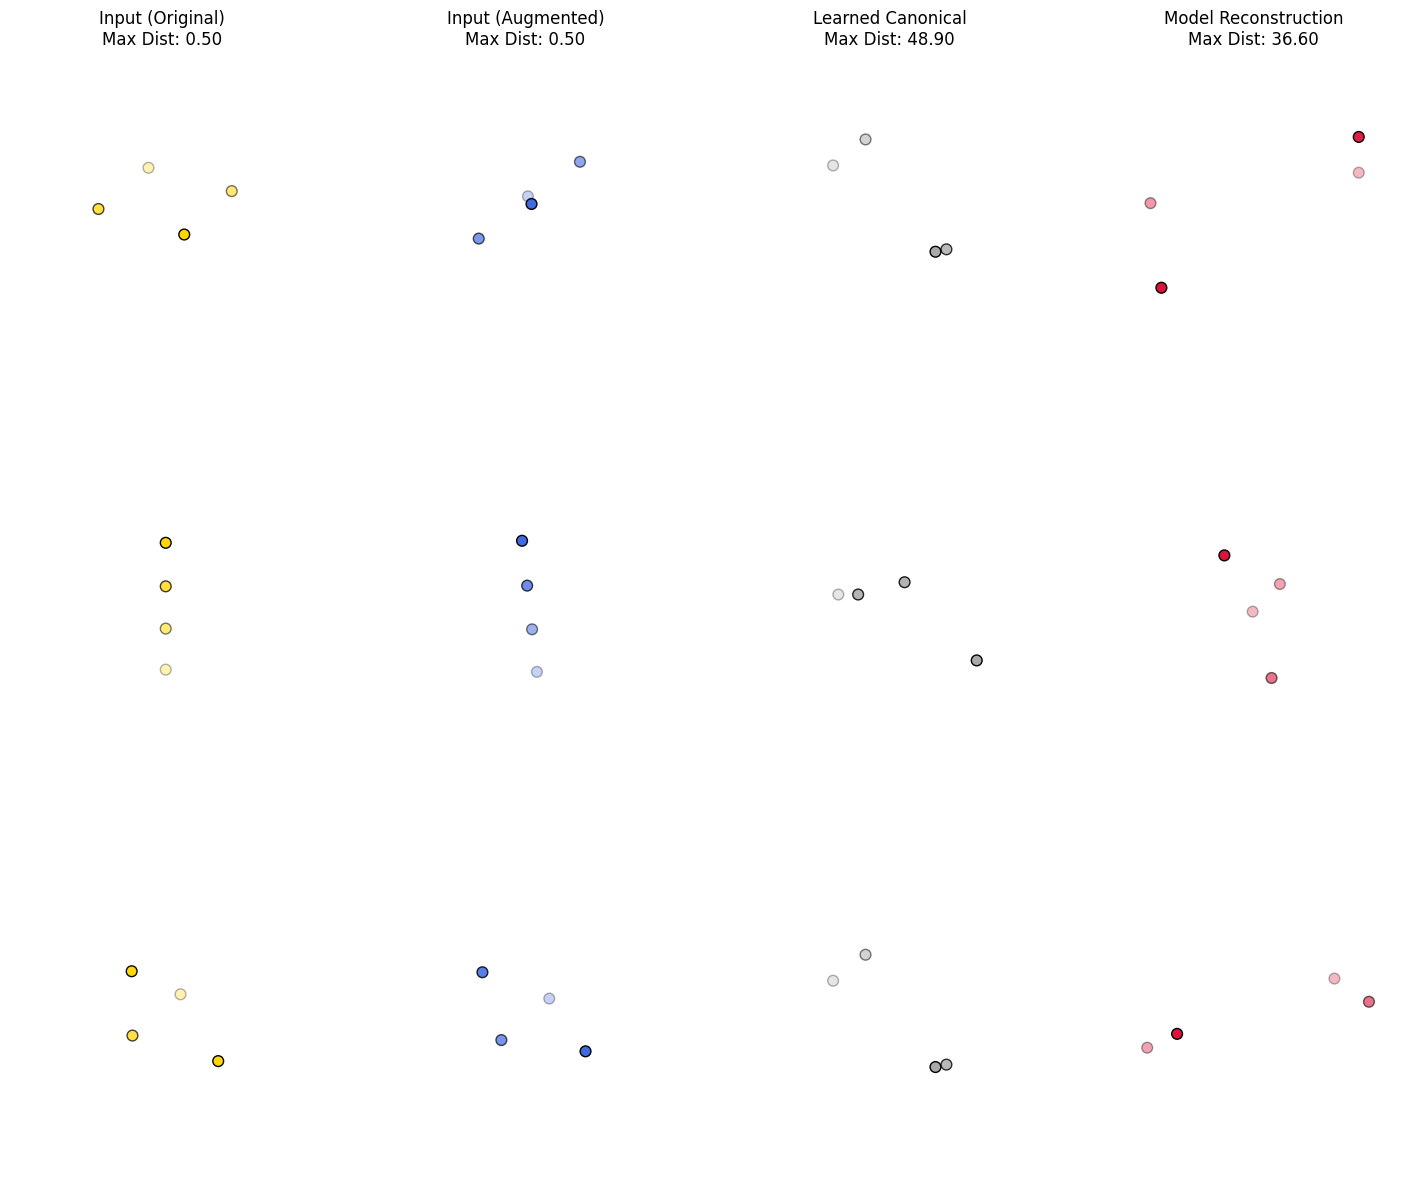


Step   10 | Loss: 6.432770
Deltas -> Inv: 1.51e-05 | Frame: 1.95e-05 | Transl: 3.31e-08

Step   20 | Loss: 1.707528
Deltas -> Inv: 8.27e-06 | Frame: 8.64e-02 | Transl: 4.30e-08

Step   30 | Loss: 0.858121
Deltas -> Inv: 2.32e-05 | Frame: 3.25e-04 | Transl: 7.45e-09

Step   40 | Loss: 0.357842
Deltas -> Inv: 8.58e-06 | Frame: 7.67e-02 | Transl: 2.98e-08

Step   50 | Loss: 0.295684
Deltas -> Inv: 3.37e-05 | Frame: 1.40e-04 | Transl: 1.41e-08

Step   60 | Loss: 0.233324
Deltas -> Inv: 9.85e-06 | Frame: 8.94e-02 | Transl: 1.99e-08

Step   70 | Loss: 0.174618
Deltas -> Inv: 3.53e-05 | Frame: 8.82e-02 | Transl: 1.99e-08

Step   80 | Loss: 0.159388
Deltas -> Inv: 1.30e-05 | Frame: 8.06e-02 | Transl: 0.00e+00

Step   90 | Loss: 0.156523
Deltas -> Inv: 2.32e-05 | Frame: 8.59e-02 | Transl: 3.97e-08

Step  100 | Loss: 0.153533
Deltas -> Inv: 7.63e-06 | Frame: 7.76e-02 | Transl: 4.64e-08

Step  110 | Loss: 0.152245
Deltas -> Inv: 1.56e-05 | Frame: 3.60e-06 | Transl: 3.64e-08

Step  120 | Loss: 0.

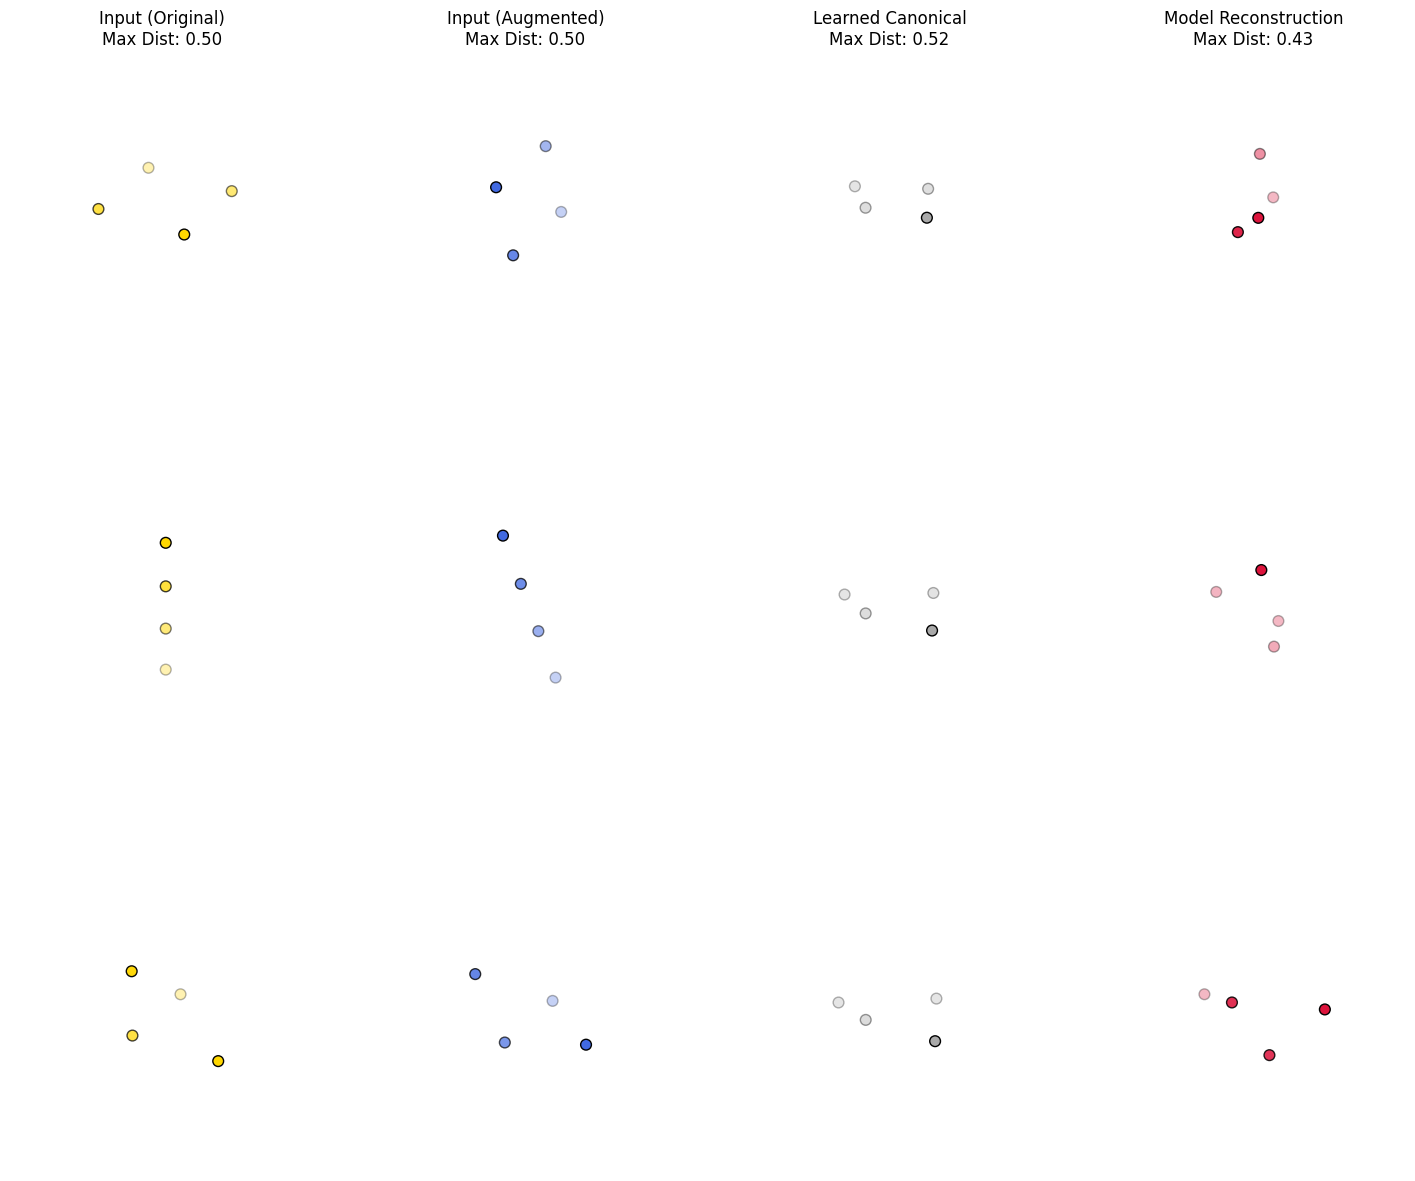


Step 1010 | Loss: 0.099143
Deltas -> Inv: 2.99e-05 | Frame: 8.91e-02 | Transl: 3.64e-08

Step 1020 | Loss: 0.098892
Deltas -> Inv: 3.47e-05 | Frame: 1.98e-06 | Transl: 4.97e-09

Step 1030 | Loss: 0.098644
Deltas -> Inv: 1.88e-05 | Frame: 7.68e-02 | Transl: 3.31e-08

Step 1040 | Loss: 0.098401
Deltas -> Inv: 1.59e-05 | Frame: 2.67e-06 | Transl: 3.31e-08

Step 1050 | Loss: 0.098159
Deltas -> Inv: 1.49e-05 | Frame: 8.42e-02 | Transl: 3.81e-08

Step 1060 | Loss: 0.097917
Deltas -> Inv: 1.81e-05 | Frame: 7.72e-02 | Transl: 4.88e-08

Step 1070 | Loss: 0.097669
Deltas -> Inv: 2.29e-05 | Frame: 4.31e-06 | Transl: 2.81e-08

Step 1080 | Loss: 0.169471
Deltas -> Inv: 9.22e-06 | Frame: 8.32e-02 | Transl: 4.64e-08

Step 1090 | Loss: 0.245368
Deltas -> Inv: 2.29e-05 | Frame: 2.43e-06 | Transl: 7.12e-08

Step 1100 | Loss: 0.158903
Deltas -> Inv: 1.97e-05 | Frame: 2.37e-06 | Transl: 3.15e-08

Step 1110 | Loss: 0.131274
Deltas -> Inv: 1.46e-05 | Frame: 8.50e-02 | Transl: 1.32e-08

Step 1120 | Loss: 0.

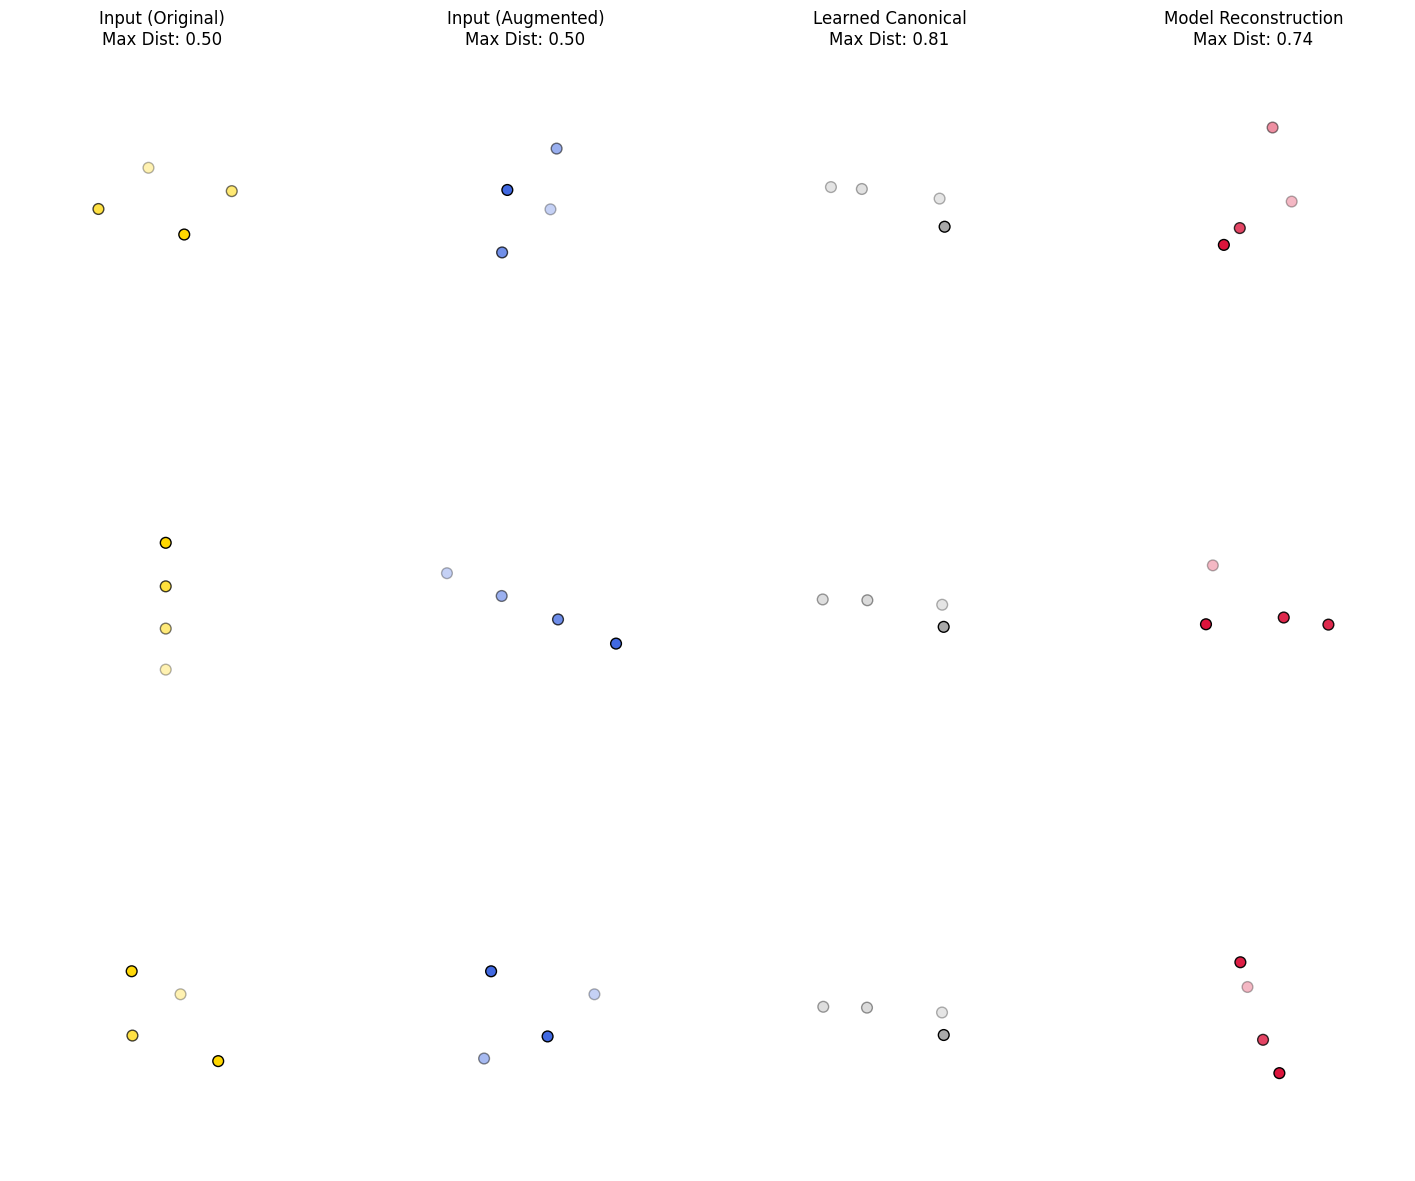


Step 2010 | Loss: 0.103782
Deltas -> Inv: 2.26e-05 | Frame: 1.83e-06 | Transl: 3.97e-08

Step 2020 | Loss: 0.103656
Deltas -> Inv: 2.48e-05 | Frame: 1.03e-06 | Transl: 3.48e-08

Step 2030 | Loss: 0.103529
Deltas -> Inv: 1.53e-05 | Frame: 1.22e-06 | Transl: 1.49e-08

Step 2040 | Loss: 0.103427
Deltas -> Inv: 2.54e-05 | Frame: 8.93e-02 | Transl: 3.31e-08

Step 2050 | Loss: 0.105090
Deltas -> Inv: 2.89e-05 | Frame: 8.65e-02 | Transl: 6.95e-08

Step 2060 | Loss: 0.192651
Deltas -> Inv: 1.78e-05 | Frame: 8.87e-02 | Transl: 1.99e-08

Step 2070 | Loss: 0.110162
Deltas -> Inv: 1.37e-05 | Frame: 2.13e-06 | Transl: 1.99e-08

Step 2080 | Loss: 0.103486
Deltas -> Inv: 2.35e-05 | Frame: 8.93e-02 | Transl: 1.32e-08

Step 2090 | Loss: 0.102774
Deltas -> Inv: 2.03e-05 | Frame: 2.80e-06 | Transl: 4.14e-10

Step 2100 | Loss: 0.102576
Deltas -> Inv: 1.21e-05 | Frame: 8.93e-02 | Transl: 1.35e-08

Step 2110 | Loss: 0.102495
Deltas -> Inv: 1.34e-05 | Frame: 1.68e-06 | Transl: 1.32e-08

Step 2120 | Loss: 0.

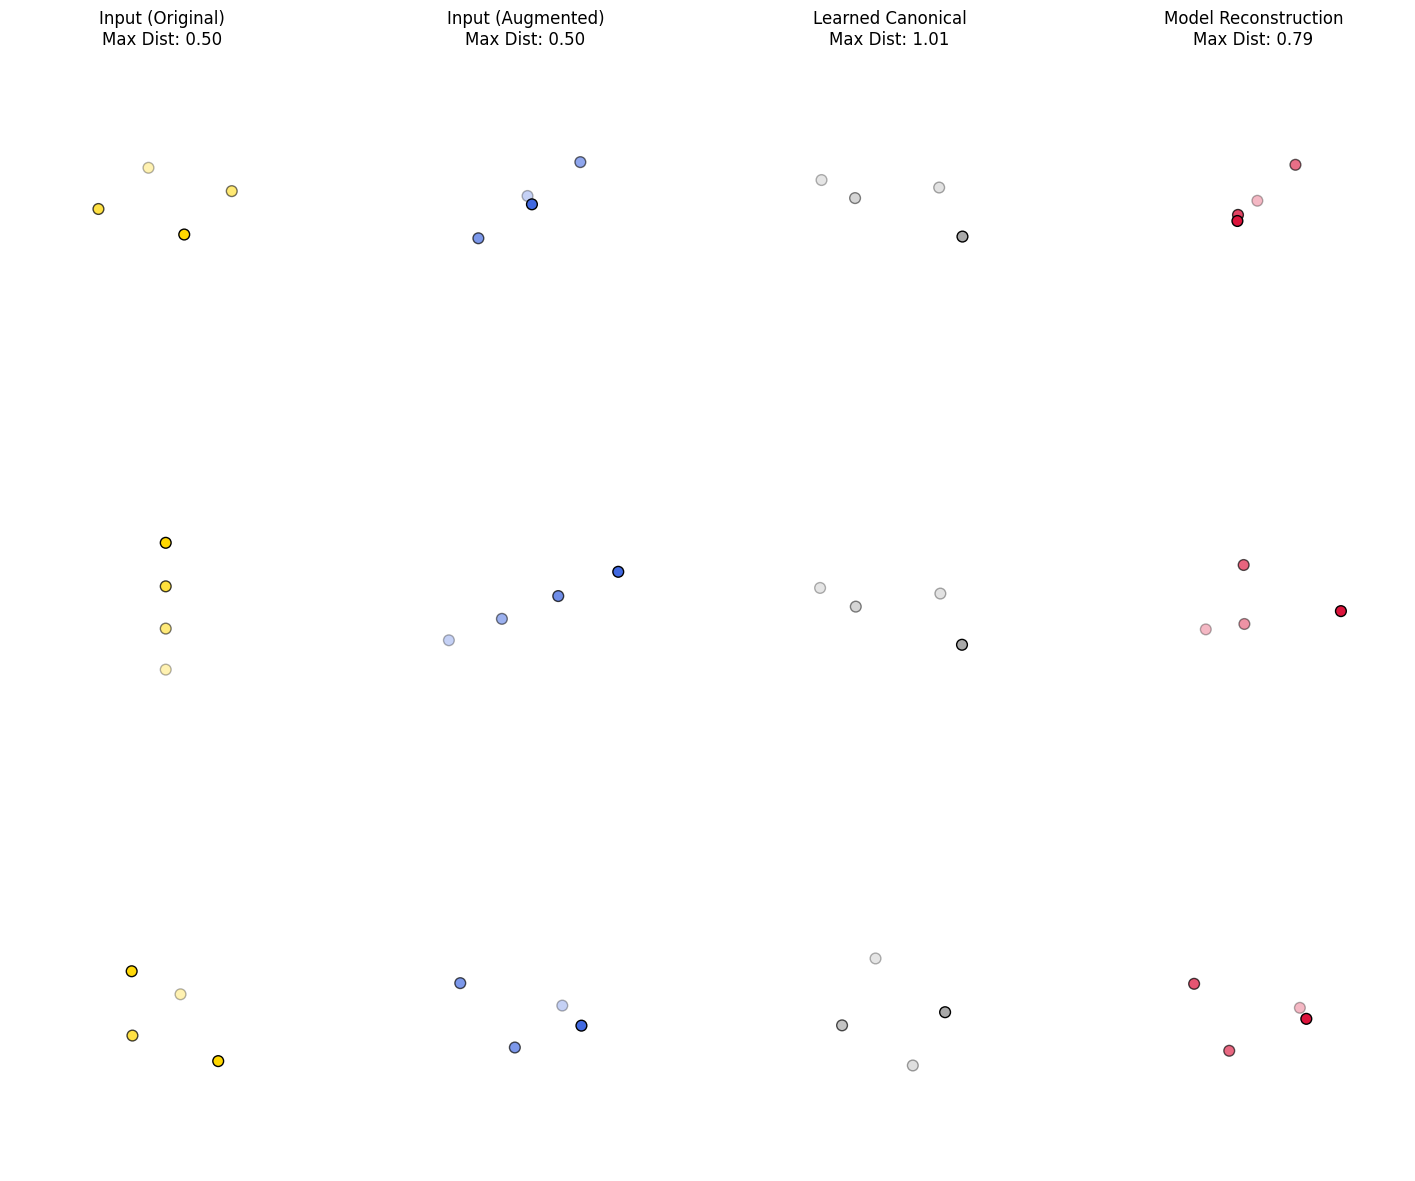


Step 3010 | Loss: 0.047096
Deltas -> Inv: 1.05e-05 | Frame: 8.51e-02 | Transl: 2.81e-08

Step 3020 | Loss: 0.046583
Deltas -> Inv: 1.65e-05 | Frame: 1.57e-06 | Transl: 1.32e-08

Step 3030 | Loss: 0.046082
Deltas -> Inv: 2.70e-05 | Frame: 8.20e-02 | Transl: 3.15e-08

Step 3040 | Loss: 0.045625
Deltas -> Inv: 3.69e-05 | Frame: 8.75e-02 | Transl: 1.66e-08

Step 3050 | Loss: 0.045198
Deltas -> Inv: 2.27e-05 | Frame: 2.60e-06 | Transl: 4.14e-08

Step 3060 | Loss: 0.044746
Deltas -> Inv: 1.64e-05 | Frame: 8.84e-02 | Transl: 1.66e-08

Step 3070 | Loss: 0.044355
Deltas -> Inv: 6.29e-05 | Frame: 8.87e-02 | Transl: 4.47e-08

Step 3080 | Loss: 0.043943
Deltas -> Inv: 1.22e-05 | Frame: 8.84e-02 | Transl: 3.31e-08

Step 3090 | Loss: 0.043600
Deltas -> Inv: 1.45e-05 | Frame: 7.51e-02 | Transl: 1.49e-08

Step 3100 | Loss: 0.043210
Deltas -> Inv: 3.59e-05 | Frame: 3.21e-06 | Transl: 3.97e-08

Step 3110 | Loss: 0.043078
Deltas -> Inv: 1.99e-05 | Frame: 8.79e-02 | Transl: 2.65e-08

Step 3120 | Loss: 0.

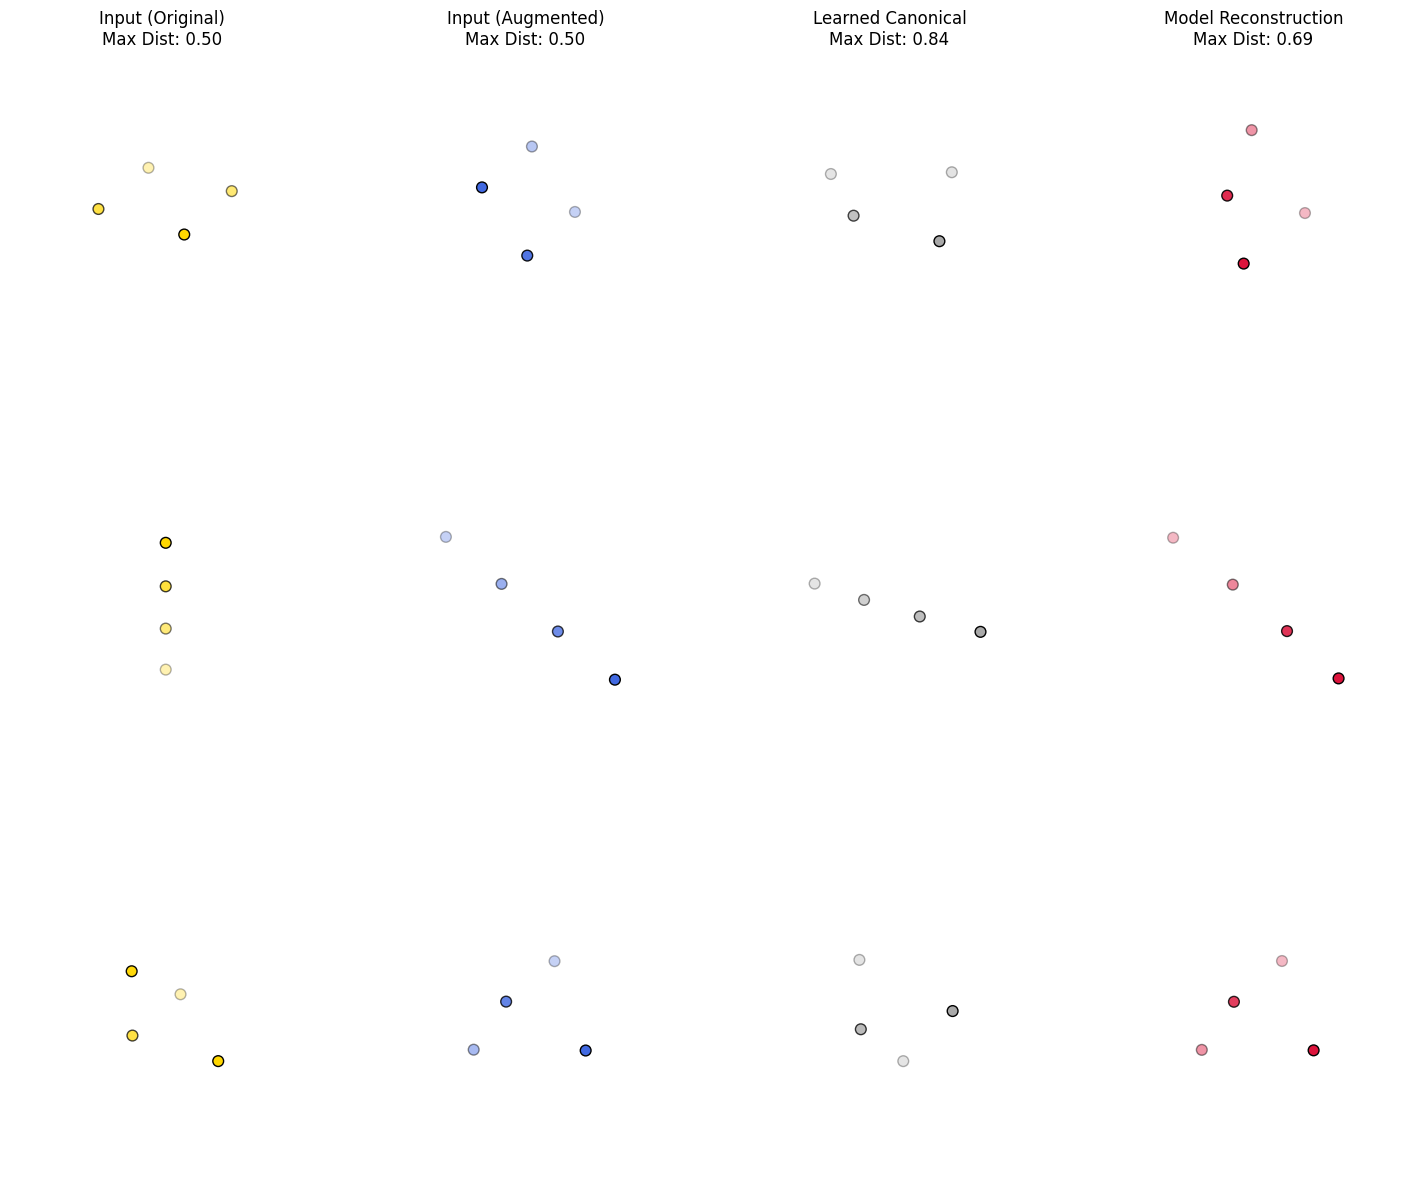


Step 4010 | Loss: 0.012332
Deltas -> Inv: 9.22e-06 | Frame: 2.75e-04 | Transl: 4.97e-08

Step 4020 | Loss: 0.012250
Deltas -> Inv: 1.49e-05 | Frame: 1.05e-04 | Transl: 4.80e-08

Step 4030 | Loss: 0.012175
Deltas -> Inv: 2.61e-05 | Frame: 8.93e-02 | Transl: 3.64e-08

Step 4040 | Loss: 0.012021
Deltas -> Inv: 3.64e-05 | Frame: 8.83e-02 | Transl: 1.32e-08

Step 4050 | Loss: 0.012044
Deltas -> Inv: 3.04e-05 | Frame: 8.06e-02 | Transl: 4.14e-08

Step 4060 | Loss: 0.011719
Deltas -> Inv: 2.05e-05 | Frame: 6.43e-04 | Transl: 3.81e-08

Step 4070 | Loss: 0.011849
Deltas -> Inv: 2.23e-05 | Frame: 1.21e-04 | Transl: 2.32e-08

Step 4080 | Loss: 0.011621
Deltas -> Inv: 1.45e-05 | Frame: 2.19e-04 | Transl: 6.29e-08

Step 4090 | Loss: 0.011510
Deltas -> Inv: 1.26e-05 | Frame: 1.19e-04 | Transl: 5.96e-08

Step 4100 | Loss: 0.011410
Deltas -> Inv: 3.16e-05 | Frame: 7.67e-02 | Transl: 4.99e-08

Step 4110 | Loss: 0.011251
Deltas -> Inv: 2.13e-05 | Frame: 8.70e-02 | Transl: 5.30e-08

Step 4120 | Loss: 0.

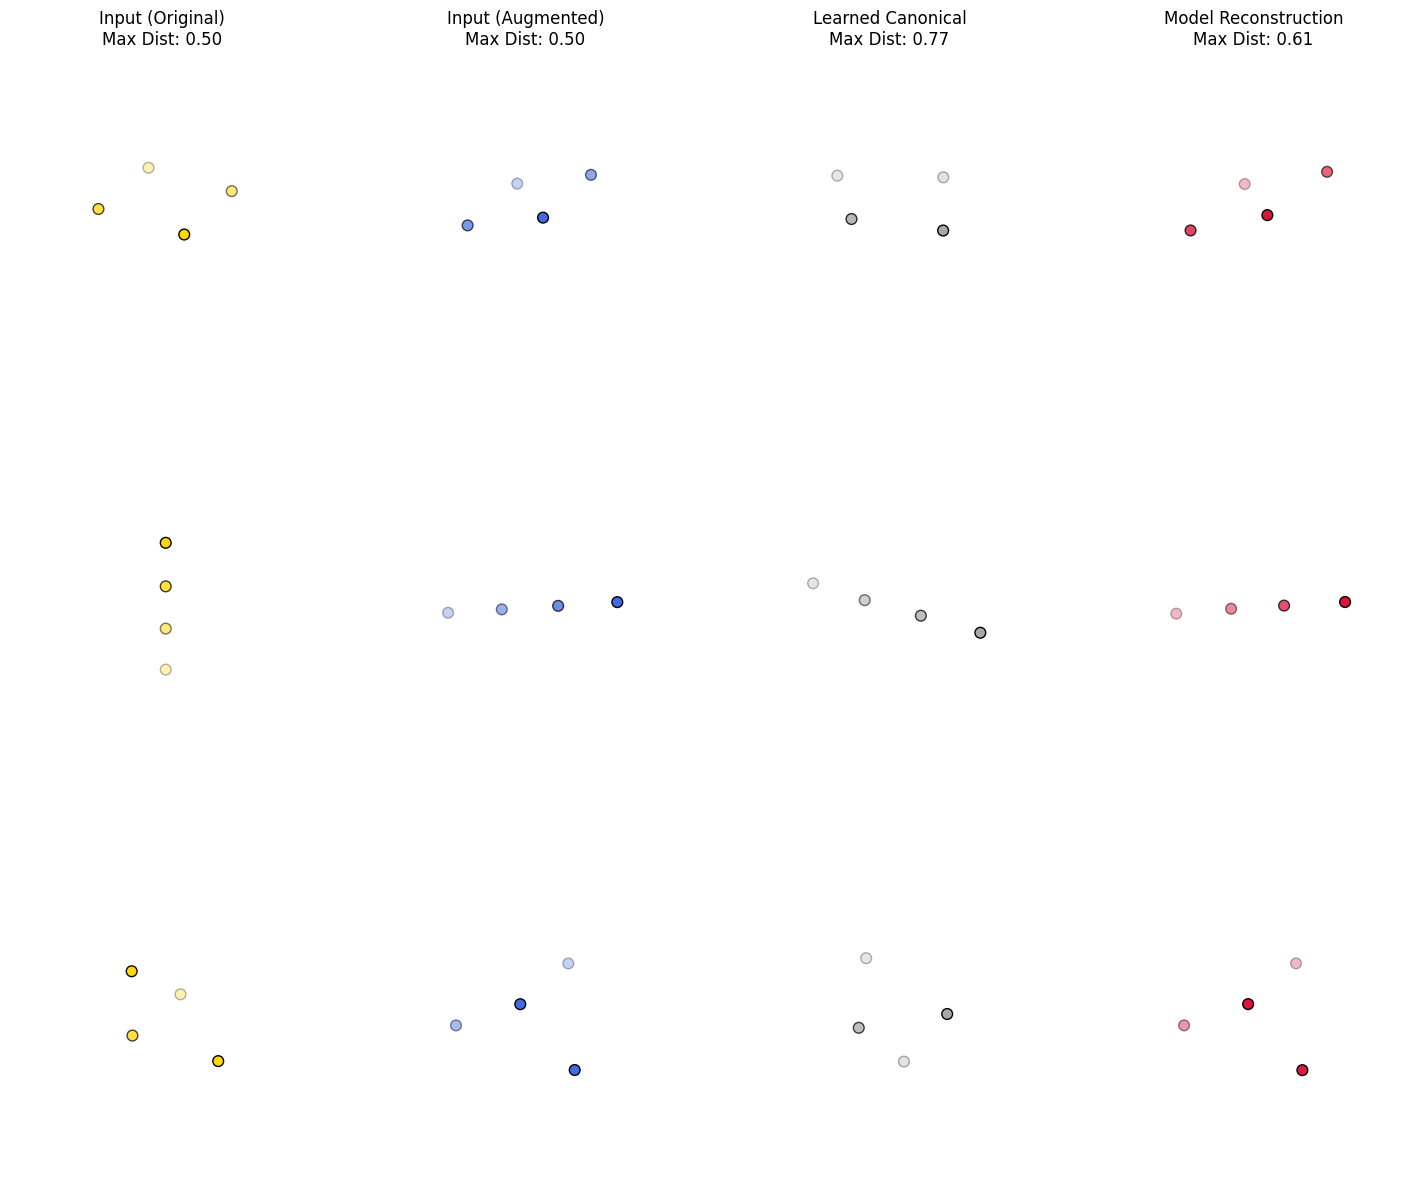


Step 5010 | Loss: 0.001794
Deltas -> Inv: 1.45e-05 | Frame: 3.35e-06 | Transl: 5.96e-08

Step 5020 | Loss: 0.001677
Deltas -> Inv: 2.99e-05 | Frame: 2.89e-06 | Transl: 2.81e-08

Step 5030 | Loss: 0.001666
Deltas -> Inv: 1.51e-05 | Frame: 7.55e-02 | Transl: 3.31e-08

Step 5040 | Loss: 0.001602
Deltas -> Inv: 2.26e-05 | Frame: 8.66e-02 | Transl: 2.69e-08

Step 5050 | Loss: 0.001628
Deltas -> Inv: 3.10e-05 | Frame: 2.81e-06 | Transl: 1.66e-08

Step 5060 | Loss: 0.001707
Deltas -> Inv: 3.26e-05 | Frame: 1.89e-06 | Transl: 3.97e-08

Step 5070 | Loss: 0.001713
Deltas -> Inv: 3.31e-05 | Frame: 8.29e-02 | Transl: 4.64e-08

Step 5080 | Loss: 0.001788
Deltas -> Inv: 2.34e-05 | Frame: 8.87e-02 | Transl: 0.00e+00

Step 5090 | Loss: 0.001251
Deltas -> Inv: 2.00e-05 | Frame: 8.86e-02 | Transl: 3.31e-08

Step 5100 | Loss: 0.002085
Deltas -> Inv: 2.64e-05 | Frame: 2.08e-06 | Transl: 6.62e-09

Step 5110 | Loss: 0.002090
Deltas -> Inv: 2.16e-05 | Frame: 8.63e-02 | Transl: 2.65e-08

Step 5120 | Loss: 0.

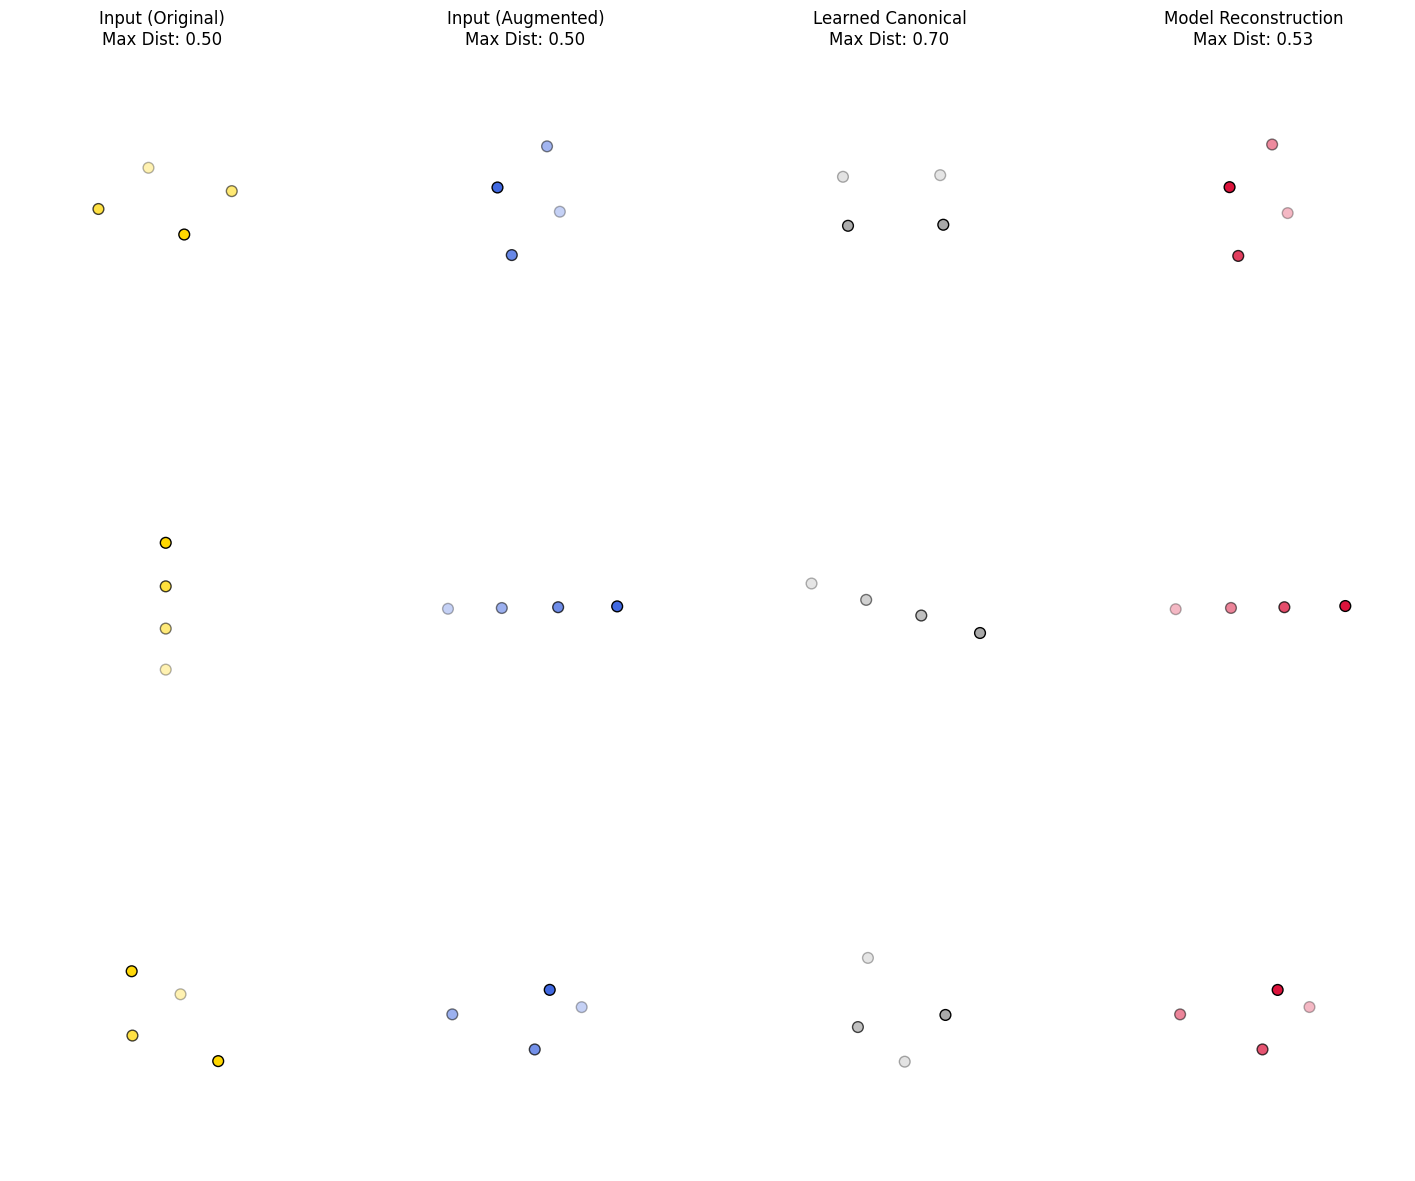


Step 6010 | Loss: 0.000243
Deltas -> Inv: 4.86e-05 | Frame: 7.71e-02 | Transl: 1.41e-08

Step 6020 | Loss: 0.000193
Deltas -> Inv: 2.34e-05 | Frame: 7.75e-02 | Transl: 4.64e-08

Step 6030 | Loss: 0.000171
Deltas -> Inv: 2.10e-05 | Frame: 7.98e-02 | Transl: 4.64e-08

Step 6040 | Loss: 0.001064
Deltas -> Inv: 4.66e-05 | Frame: 3.29e-06 | Transl: 3.31e-08

Step 6050 | Loss: 0.003738
Deltas -> Inv: 4.47e-05 | Frame: 1.46e-06 | Transl: 4.64e-08

Step 6060 | Loss: 0.006713
Deltas -> Inv: 1.88e-05 | Frame: 7.87e-02 | Transl: 1.32e-08

Step 6070 | Loss: 0.002865
Deltas -> Inv: 2.85e-05 | Frame: 8.38e-02 | Transl: 0.00e+00

Step 6080 | Loss: 0.000233
Deltas -> Inv: 2.81e-05 | Frame: 8.48e-02 | Transl: 1.99e-08

Step 6090 | Loss: 0.000241
Deltas -> Inv: 3.31e-05 | Frame: 5.72e-06 | Transl: 6.29e-08

Step 6100 | Loss: 0.000209
Deltas -> Inv: 4.13e-05 | Frame: 8.91e-02 | Transl: 6.62e-09

Step 6110 | Loss: 0.000165
Deltas -> Inv: 2.92e-05 | Frame: 3.09e-06 | Transl: 3.31e-09

Step 6120 | Loss: 0.

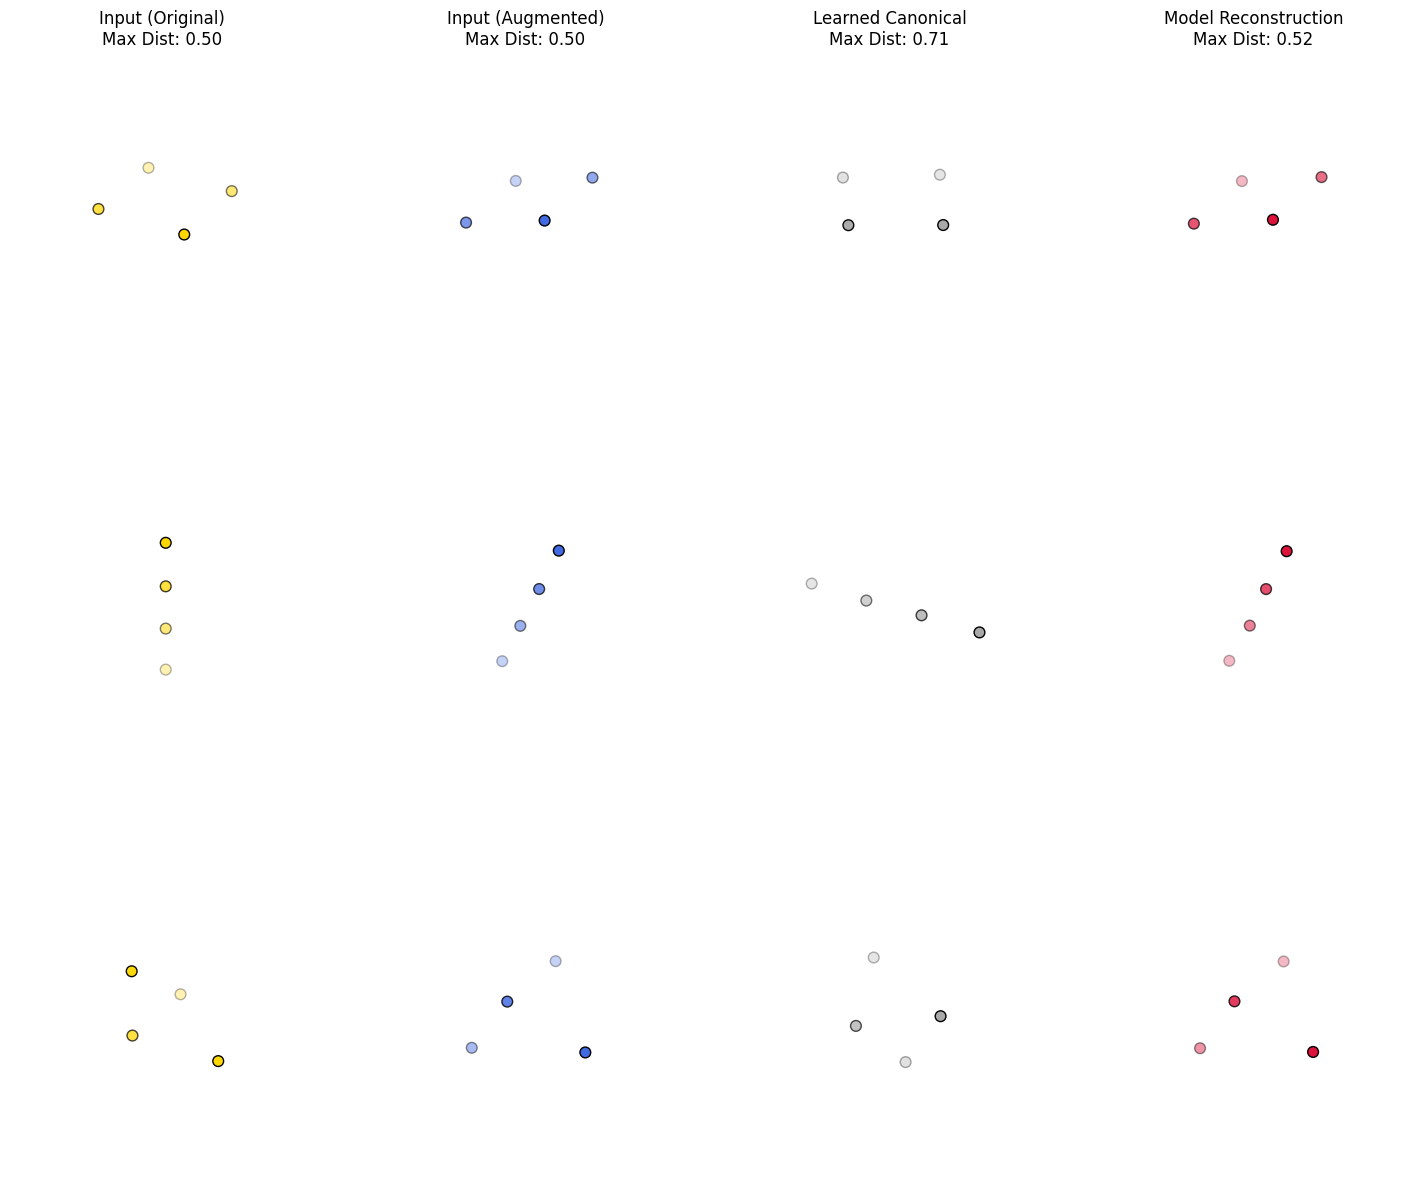


Step 7010 | Loss: 0.000131
Deltas -> Inv: 3.83e-05 | Frame: 7.80e-02 | Transl: 2.98e-08

Step 7020 | Loss: 0.000121
Deltas -> Inv: 2.13e-05 | Frame: 8.59e-02 | Transl: 1.32e-08

Step 7030 | Loss: 0.000108
Deltas -> Inv: 3.07e-05 | Frame: 3.65e-06 | Transl: 2.98e-08

Step 7040 | Loss: 0.000094
Deltas -> Inv: 1.83e-05 | Frame: 8.69e-02 | Transl: 6.62e-09

Step 7050 | Loss: 0.000090
Deltas -> Inv: 1.16e-05 | Frame: 8.62e-02 | Transl: 3.31e-08

Step 7060 | Loss: 0.000092
Deltas -> Inv: 2.19e-05 | Frame: 8.92e-02 | Transl: 4.30e-08

Step 7070 | Loss: 0.000118
Deltas -> Inv: 2.70e-05 | Frame: 5.03e-06 | Transl: 2.81e-08

Step 7080 | Loss: 0.000295
Deltas -> Inv: 1.29e-05 | Frame: 8.93e-02 | Transl: 2.65e-08

Step 7090 | Loss: 0.000560
Deltas -> Inv: 1.51e-05 | Frame: 7.51e-02 | Transl: 1.66e-08

Step 7100 | Loss: 0.000732
Deltas -> Inv: 1.59e-05 | Frame: 8.91e-02 | Transl: 4.64e-08

Step 7110 | Loss: 0.000276
Deltas -> Inv: 2.57e-05 | Frame: 8.55e-02 | Transl: 5.63e-08

Step 7120 | Loss: 0.

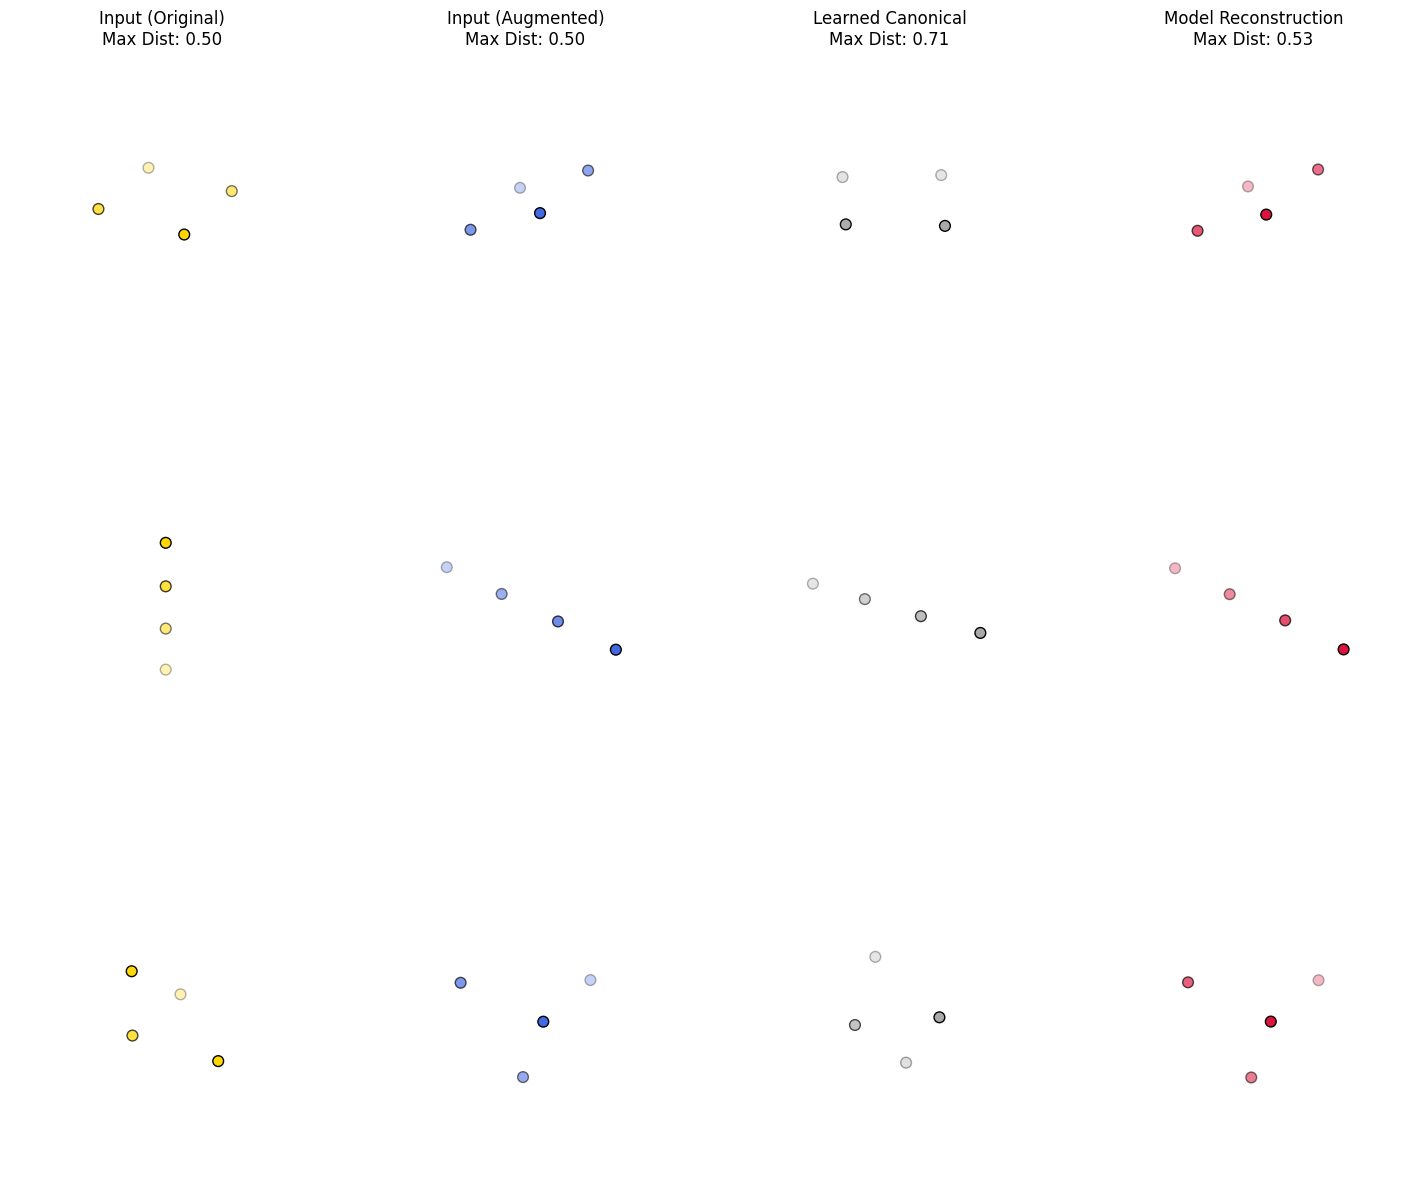


Step 8010 | Loss: 0.000126
Deltas -> Inv: 1.00e-05 | Frame: 1.04e-06 | Transl: 5.30e-08

Step 8020 | Loss: 0.000108
Deltas -> Inv: 2.34e-05 | Frame: 7.71e-02 | Transl: 8.28e-09

Step 8030 | Loss: 0.000085
Deltas -> Inv: 1.18e-05 | Frame: 1.80e-06 | Transl: 3.97e-08

Step 8040 | Loss: 0.000072
Deltas -> Inv: 3.51e-05 | Frame: 8.41e-02 | Transl: 2.65e-08

Step 8050 | Loss: 0.000059
Deltas -> Inv: 3.27e-05 | Frame: 8.11e-02 | Transl: 6.62e-09

Step 8060 | Loss: 0.000052
Deltas -> Inv: 1.35e-05 | Frame: 8.10e-02 | Transl: 1.66e-08

Step 8070 | Loss: 0.000044
Deltas -> Inv: 2.57e-05 | Frame: 2.10e-06 | Transl: 4.14e-08

Step 8080 | Loss: 0.000040
Deltas -> Inv: 2.10e-05 | Frame: 2.42e-06 | Transl: 2.65e-08

Step 8090 | Loss: 0.000034
Deltas -> Inv: 1.62e-05 | Frame: 8.70e-02 | Transl: 3.31e-08

Step 8100 | Loss: 0.000030
Deltas -> Inv: 3.77e-05 | Frame: 8.94e-02 | Transl: 5.96e-08

Step 8110 | Loss: 0.000027
Deltas -> Inv: 2.30e-05 | Frame: 7.83e-02 | Transl: 2.98e-08

Step 8120 | Loss: 0.

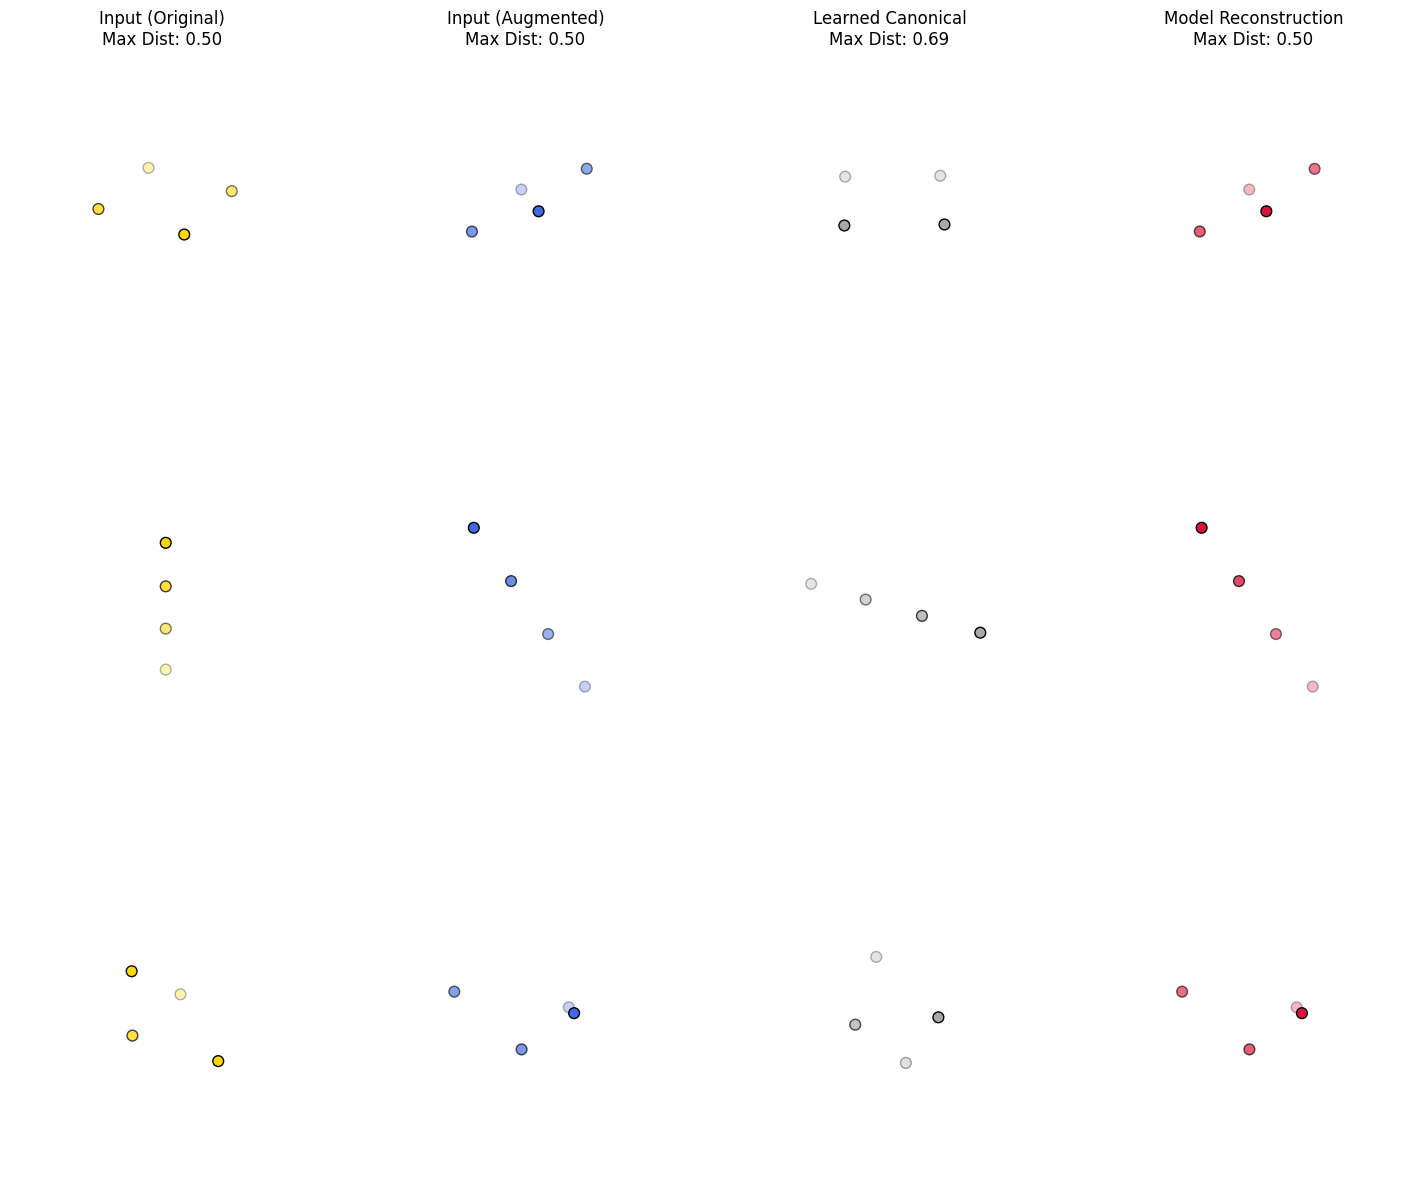


Step 9010 | Loss: 0.000010
Deltas -> Inv: 2.15e-05 | Frame: 8.58e-02 | Transl: 4.64e-08

Step 9020 | Loss: 0.000863
Deltas -> Inv: 9.70e-06 | Frame: 8.80e-02 | Transl: 2.15e-08

Step 9030 | Loss: 0.000208
Deltas -> Inv: 1.84e-05 | Frame: 8.80e-02 | Transl: 4.30e-08

Step 9040 | Loss: 0.000066
Deltas -> Inv: 1.24e-05 | Frame: 8.93e-02 | Transl: 1.57e-08

Step 9050 | Loss: 0.000049
Deltas -> Inv: 1.99e-05 | Frame: 1.68e-06 | Transl: 2.15e-08

Step 9060 | Loss: 0.000031
Deltas -> Inv: 1.30e-05 | Frame: 1.19e-06 | Transl: 3.64e-08

Step 9070 | Loss: 0.000014
Deltas -> Inv: 7.79e-06 | Frame: 8.65e-02 | Transl: 1.99e-08

Step 9080 | Loss: 0.000006
Deltas -> Inv: 2.27e-05 | Frame: 1.96e-06 | Transl: 1.32e-08

Step 9090 | Loss: 0.000004
Deltas -> Inv: 1.56e-05 | Frame: 8.18e-02 | Transl: 4.64e-08

Step 9100 | Loss: 0.000002
Deltas -> Inv: 3.26e-05 | Frame: 8.12e-02 | Transl: 6.62e-09

Step 9110 | Loss: 0.000001
Deltas -> Inv: 2.89e-05 | Frame: 1.52e-06 | Transl: 2.65e-08

Step 9120 | Loss: 0.

In [ ]:
# Usage:
from flax.training import train_state
import optax
trainer = TetrisTrainer(EquivModel(), ShapeDecoder())
final_state, final_preds = trainer.fit(tetris_graphs, num_steps=10000, log_every = 10, plot_every = 1000)

Success! We were able to learn an SE(3) invariant latent space by simultaneously predicitng the group action. This consistent with the paper Unsupervised Learning of Group Invariant and Equivariant Representations. Instead of using Vector Neurons, the code has been implemented with e3nn. Furthermore, we learned a bit about deep learning applications in jax.